# Code Initialization

In [101]:
from qiskit import QuantumCircuit, transpile, QuantumRegister
from qiskit_aer import AerSimulator, QasmSimulator, Aer
# from qiskit_ibm_runtime import QiskitRuntimeService, Session, Sampler, Estimator, Options
from qiskit_ibm_runtime import QiskitRuntimeService, Session, Options
from qiskit_ibm_runtime import Sampler, SamplerV2
from qiskit.visualization import plot_histogram
from qiskit.circuit.classical import expr

from datetime import datetime
import mysql.connector
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re
from qiskit_aer.noise import (NoiseModel, QuantumError, ReadoutError, reset_error,
    pauli_error, depolarizing_error, thermal_relaxation_error)
import json

from qiskit_ibm_runtime.fake_provider import fake_backend

import copy
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi
from qiskit.qasm2 import dumps
from qiskit.visualization import plot_circuit_layout

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RZZGate, RZGate, XGate, IGate
from qiskit.converters import circuit_to_dag, dag_to_circuit

from qiskit.transpiler.passes import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling, PadDelay
from qiskit.transpiler import PassManager
import numpy as np
from qiskit.qasm2 import dumps
from random import randint

import json
from qiskit_ibm_runtime import RuntimeEncoder, RuntimeDecoder

import mthree
import stim
import time


CB_color_cycle = [
    '#006BA4',  # Blue
    '#FF800E',  # Orange
    '#ABABAB',  # Gray
    '#595959',  # Dark Gray
    '#5F9ED1',  # Light Blue
    '#C85200',  # Dark Orange
    '#898989',  # Medium Gray
    '#A2C8EC',  # Pale Blue
    '#FFBC79',  # Light Orange
    '#CFCFCF',  # Light Gray
    '#009E73',  # Green (Colorblind-friendly)
    '#F0E442'   # Yellow (Colorblind-friendly)
]

markers = ['o', 'v', '^', 's', '+', '*', 'x', 'd', '<', '>', 'p']
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':']

# MySQL connection parameters
mysql_config = {
    'user': 'handy',
    'password': 'handy',
    'host': 'localhost',
    'database': 'framework'
}

shots = 4000

mysql_config_online = {
    'user': 'handy',
    'password': 'handy',
    'host': 'ec2-16-171-135-24.eu-north-1.compute.amazonaws.com',
    'database': 'calibration_data'
}

import os
import sys

#module_path = os.path.abspath(os.path.join('..', 'functions'))
#if module_path not in sys.path:
#    sys.path.append(module_path)

from commons import (
    used_qubits, sum_middle_digits_dict
)

from commons import (Config, convert_utc_to_local, calculate_time_diff, get_count_1q, get_count_2q, 
    calculate_circuit_cost, get_correct_output_dict, calculate_success_rate_nassc, calculate_success_rate_tvd, 
    calculate_success_rate_polar, calculate_hellinger_distance, calculate_success_rate_tvd_new, 
    convert_to_json, is_mitigated, get_initial_mapping_json, normalize_counts, convert_dict_int_to_binary, reverse_string_keys, convert_dict_binary_to_int,
    sum_middle_digits_dict
)

from wrappers.multiprogramming_wrapper import (
    avoid_simultaneous_cnot, add_zz_on_simultaneous_cnot, 
    build_idle_coupling_map, multiprogram_compilation_qiskit, merge_circuits,
    get_LF_presets_cm
)
from wrappers.polar_wrapper import (
        polar_code_p2, get_logical_error_on_accepted_states, get_q1prep_sr, get_i_position, make_polar_qc_based_p2,
divide_half_list, get_q1prep_accepted_states
)

from wrappers.prune_wrapper import (
    create_full_graph, generate_figures, generate_node_errors, generate_edge_errors,
    get_latest_calibration_id, get_edges_threshold, get_readout_threshold, get_LF_qubits
)

from wrappers.dd_wrapper import (
    convert_dt_to_us, count_delay_durations, apply_pad_delay, get_delay_information, get_dd_information, 
    get_delay_and_dd_information_us
)

from wrappers.qiskit_wrapper import (
    apply_dd, get_zz_rates_from_backend_in_hz, get_qubits_T1_T2, get_gates_length, generate_errors_thermal_relaxation, 
generate_thermal_noise_model_on_used_qubits, get_neighbor_zz_rates_by_qubit, create_rzz_operator,
replace_delay_with_rzz, get_initial_layout_from_circuit
)

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

 
# token = "476ea8c61cc54f36e4a21d70a8442f94203c9d87096eaad0886a3e8154d8c2e79bcad6f927c6050a76335dd68d783f478c1b828504748a4377b441c335c831aa"

# frisbee_among.0p@icloud.com
token = "04ede7f82299b792eae4daf3581f62415b3af676370f752f52d40e5851c7201d6e357c36e7bd55e4719c80d66bba7474412253f6c62f0ea7577bf056aa92eb62"

# # chores.acetone-0t@icloud.com
# token = "108bce3fd4c7a849d27b3eb41aad83f0c0a4f523cf6f3aa9735390405604613e51b9fc092722ef709554d9bb88a9dccd882eadeeadc590e554a8447fef8c8f97"

QiskitRuntimeService.save_account(channel="ibm_quantum", token=token, overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum", token=token)


# token = "23OwipXqZzd8plKZR2LDMK-peWuU74UQAyjAhMIaFHCM"
# QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=token, instance="free", overwrite=True)
# service = QiskitRuntimeService(channel="ibm_quantum_platform", token=token, instance="free")

# hw_name = "ibm_brisbane"
hw_name = "ibm_sherbrooke"
backend = service.backend(hw_name)

sim_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend)

## change later back to 3
pm = generate_preset_pass_manager(
    optimization_level=3, backend=backend
    #, seed_transpiler=12345
)

def extract_z_syndrome(circuit, target, controls, measure):
    circuit.cx(controls[0], target)
    circuit.cx(controls[1], target)
    circuit.measure(target, measure)

    #with circuit.if_test((measure, True)):
    #    circuit.x(controls[0])

    #circuit.reset(target)

def extract_x_syndrome(circuit, target, controls, measure):
    circuit.h(target)
    circuit.cx(target, controls[0])
    circuit.cx(target, controls[1])
    circuit.h(target)
    circuit.measure(target, measure)





/tmp/ipykernel_105506/2247412880.py:139: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = QiskitRuntimeService(channel="ibm_quantum", token=token)


In [5]:
def generate_circuit_extraction_syndrome(k, meas_type, x_first = False):
    num_qbits = (2**k) + (2**(k-1))
    num_cbits = 2**(k-1)

    qc = QuantumCircuit(num_qbits, num_cbits)

    data_qubits = []
    ancillas = []
    for i in range(2**(k-1)):
        ancillas.append(i *3 + 2)

    for i in range(num_qbits):
        if i not in ancillas:
            data_qubits.append(i)

    d1, d2 = divide_half_list(data_qubits)
    #print(d1,d2, ancillas)

    for idx in range(len(d1)):

        if meas_type.lower() == "x":

            if x_first:
                qc.h(d1[idx])
                qc.cx(d1[idx], d2[idx])
            else:
                qc.h(ancillas[idx])
                qc.cx(ancillas[idx], d1[idx])
                qc.cx(ancillas[idx], d2[idx])
                qc.h(ancillas[idx])
                
                # qc.measure(ancillas[idx], idx)
                # qc.reset(ancillas[idx])

        elif meas_type.lower() == "z":
            qc.cx(d1[idx], ancillas[idx])
            qc.cx(d2[idx], ancillas[idx])

            # qc.measure(ancillas[idx], idx)
            # qc.reset(ancillas[idx])
    
    return qc

qc_x1 = generate_circuit_extraction_syndrome(1, "x", False)
qc_x1_first = generate_circuit_extraction_syndrome(1, "x", True)
qc_x2 = generate_circuit_extraction_syndrome(2, "x")
qc_x3 = generate_circuit_extraction_syndrome(3, "x")
qc_x4 = generate_circuit_extraction_syndrome(4, "x")
qc_x5 = generate_circuit_extraction_syndrome(5, "x")

qc_z2 = generate_circuit_extraction_syndrome(2, "z")
qc_z3 = generate_circuit_extraction_syndrome(3, "z")
qc_z4 = generate_circuit_extraction_syndrome(4, "z")
qc_z5 = generate_circuit_extraction_syndrome(5, "z")



#qc_x2.draw("mpl")



# Optimizing factory-based approach of state preparation of quantum polar code by using Dynamic Circuits

## Motivation

- The control-flow operation (IfElseOp) can be used to reduce number of gates depends on the previous mid-circuit measurement results.
- In the state preparation of quantum polar code, by using the error detection gadget, we could skip gates if error is detected
- Skipping gates also reduce the usage of quantum resources (iif dynamic circuit speed has been improved)



## Goal

- Reducing the usage of quantum and classical resources

## Hyphotheses

1. By skipping gates if an error is detected will reduce the usage of quantum resource.
2. Using classical bits (cbits) as a flag can reduce the classical resource usage as discarding the flagged measurement result.


### Hyphothesis 1: Reducing the Quantum Resource

__NOTE: based on the information here (https://docs.quantum.ibm.com/announcements/product-updates/2025-03-03-new-version-dynamic-circuits)__

To accelerate the rollout, we have deprecated the following capabilities:
- The `while`, `for`, and `switch` control flow constructs
- The ability to use control flow instructions inside the body of a branch (as in, nested control flow)
- Conditional measurements

#### Goal

__To reduce the usage of quantum resource by skipping gates if an error is detected at earlier stage__

#### Metric

1. Number of Operations 
2. Quantum Resource usage (simulation + real hardware)
3. Preparation rate + logical error rate


### Hyphothesis 2: Reducing the Classical Resource

#### Goal

__To reduce the usage of classical resource by skipping flagged measurement result__

#### Metric

1. Detection time
2. Decoding time


## Methodology

### Circuit Synthesize

As in our case, we initialized all the qubits in |0>, we can simplify the first layer from:


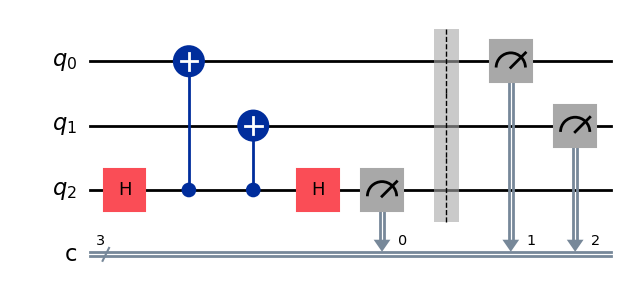

In [6]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

for i in range(1):
    start = i * 3 
    qc.append(qc_x1, range(start, start + 3), [i])

qc.measure(2,0)
qc.barrier()
qc.measure(0,1)
qc.measure(1,2)

qc.decompose().draw("mpl")

if $q_2$ is measured in $|0\rangle$, then qubits $q_0$, and $q_1$ will be in $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$, otherwise it would be $|\Phi^-\rangle = \frac{1}{\sqrt{2}}(|00\rangle - |11\rangle)$.



In [7]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'000': 956, '110': 1043, '001': 993, '111': 1008}

As all qubits are initialized in $|0\rangle$, we can modify the circuit with mid-circuit measurement and feed-forward control

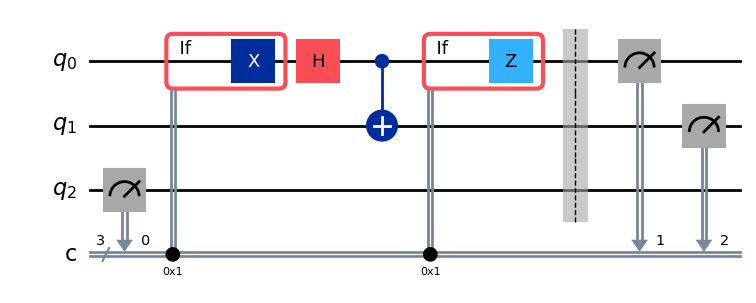

In [8]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

qc.measure(2,0)

with qc.if_test((creg,1)) as else_:
    qc.x(0)

qc.h(0)
qc.cx(0,1)
with qc.if_test((creg,1)) as else_:
    qc.z(0)

qc.barrier()
qc.measure(0,1)
qc.measure(1,2)
qc.draw("mpl")



In [9]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'110': 1978, '000': 2022}

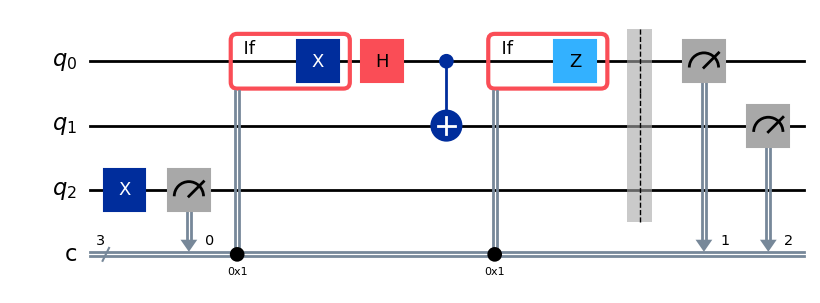

In [10]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

qc.x(2)
qc.measure(2,0)

with qc.if_test((creg,1)) as else_:
    qc.x(0)

qc.h(0)
qc.cx(0,1)
with qc.if_test((creg,1)) as else_:
    qc.z(0)

qc.barrier()
qc.measure(0,1)
qc.measure(1,2)
qc.draw("mpl")



In [11]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count

{'001': 2004, '111': 1996}

The result are the same it differs only by the global phase if the measurement of $q_2 = 1$.

Now, to simplify this more, as we now that all the qubits are initialized in $|0\rangle$, we can change the circuit to:

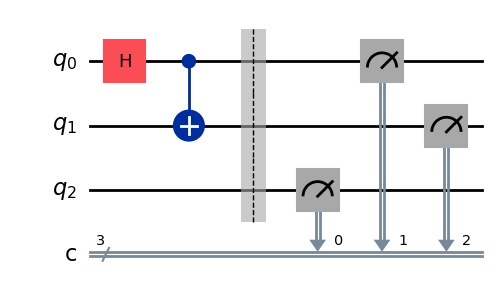

In [12]:
qreg = QuantumRegister(3, name="q")
creg = ClassicalRegister(3, name="c")
qc = QuantumCircuit(qreg,creg)

qc.h(0)
qc.cx(0,1)

qc.barrier()
qc.measure(2,0)
qc.measure(0,1)
qc.measure(1,2)
qc.draw("mpl")

In [13]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count

{'000': 2032, '110': 1968}

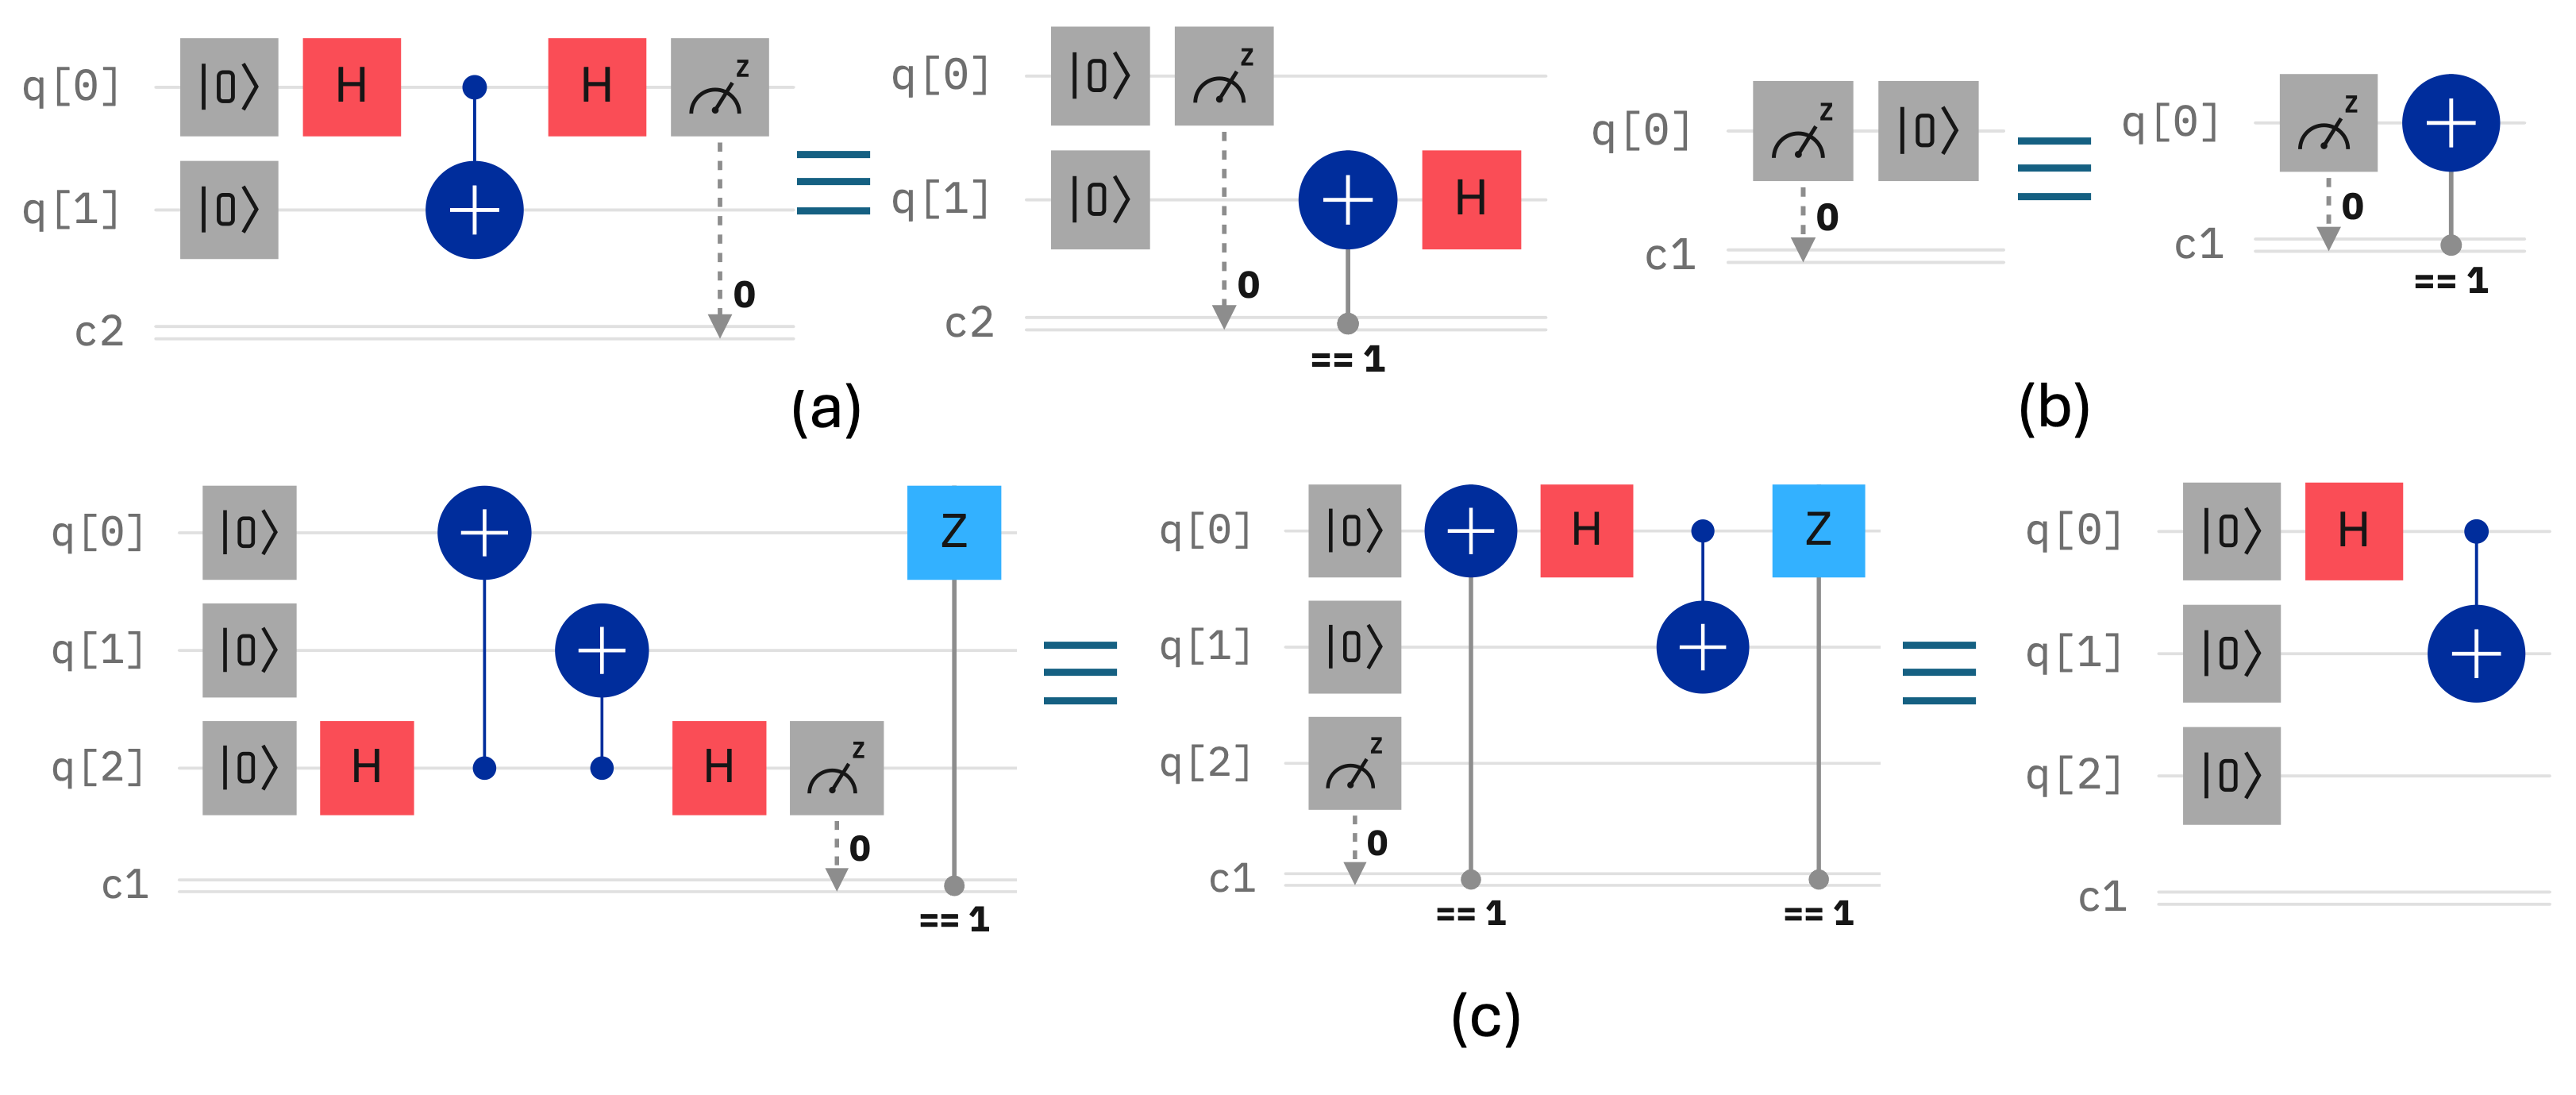

The goal of this approach is:
- to simplify the variance in the entanglement
- to reduce the number of gates and operation as the error rate at the first layer is small

### Error Detection

As the correct states have been known, we can detect if there is an error from the syndrome extraction circuit.

For example with this circuit, it has both z-syndrome extraction and x-syndrome extraction.

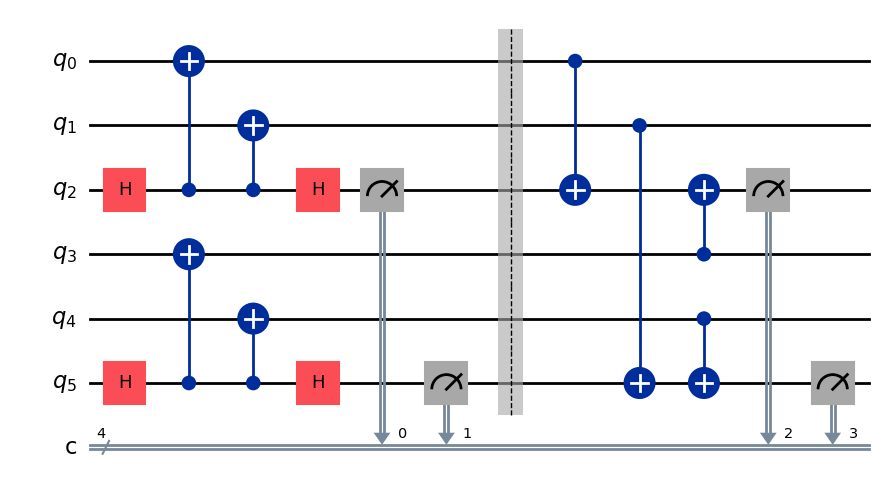

In [14]:
qreg = QuantumRegister(6, name="q")
creg = ClassicalRegister(4, name="c")
qc = QuantumCircuit(qreg,creg)

for i in range(2):
    start = i * 3 
    qc.append(qc_x1, range(start, start + 3), [i])


qc.measure(2,0)
qc.measure(5,1)

qc.barrier()

qc.append(qc_z2, range(6), range(2))

qc.measure(2,2)
qc.measure(5,3)

qc.decompose().draw("mpl")


In [15]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'0011': 480,
 '0101': 499,
 '0000': 526,
 '1010': 496,
 '1001': 511,
 '1100': 482,
 '1111': 516,
 '0110': 490}

In this case we can apply this simplification from the "Circuit Synthesize" to the circuit above:

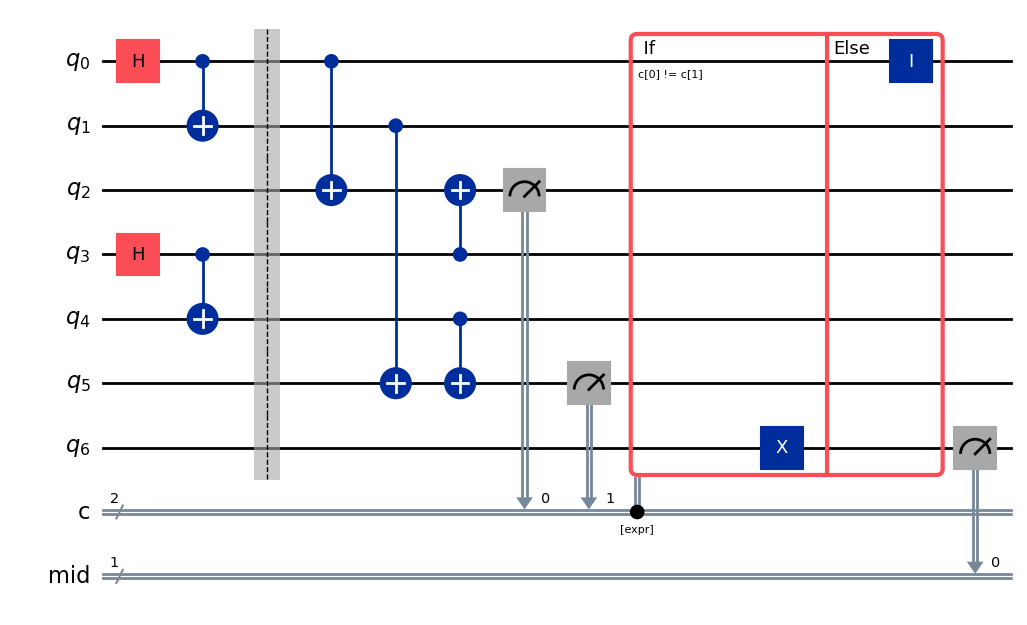

In [16]:
qreg = QuantumRegister(7, name="q")
creg = ClassicalRegister(2, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg, mid)

for i in range(2):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])


qc.barrier()

qc.append(qc_z2, range(6), range(2))

qc.measure(2,0)
qc.measure(5,1)

qc = qc.decompose()

expr_1 = expr.not_equal(creg[0], creg[1])
with qc.if_test(expr_1) as else_:
    qc.x(6)
with else_:
    qc.id(0)

# with the new update from IBM, measurement inside the control-flow is not possible
qc.measure(6,mid)
    
qc.draw("mpl")

In [17]:
tqc = pm.run(qc)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'0 00': 2036, '0 11': 1964}

So, the possible outcome in the absence of noise from the above entangled states are either "00" or "11". So, if we simulate them on the noisy simulator we will have:

In [18]:
tqc = pm.run(qc)
result = sim_noisy.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'0 01': 1,
 '1 00': 8,
 '1 01': 127,
 '1 10': 99,
 '0 10': 1,
 '0 00': 1861,
 '1 11': 5,
 '0 11': 1898}

So, know we can determine if the result that we get other than "00" and "11", there will be some error somewhere along the circuit.



#### Generalized Error Detection

## Implementation

### Experimental Setup

- Backend: __ibm_sherbrooke__ (v.1.6.112 as of 24 June 2025)
- Shots: __5000__
- Connectivity: __2/3__
- Circuits: __State preparation of Quantum Polar Code__

Error rates:
- 2Q error (best) : 2.33e-3
- 2Q error (layered) : 1.43e2
  

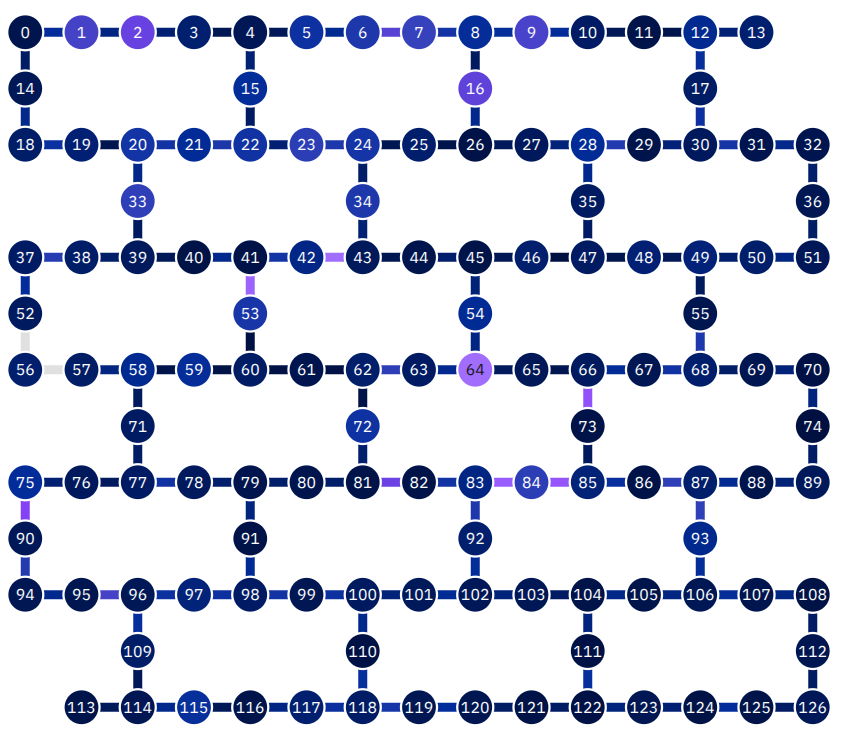

### $n=3$, $i=4$ for logical $|0\rangle$, b = 110


n = 3 , b = 110 (3) , i = 4


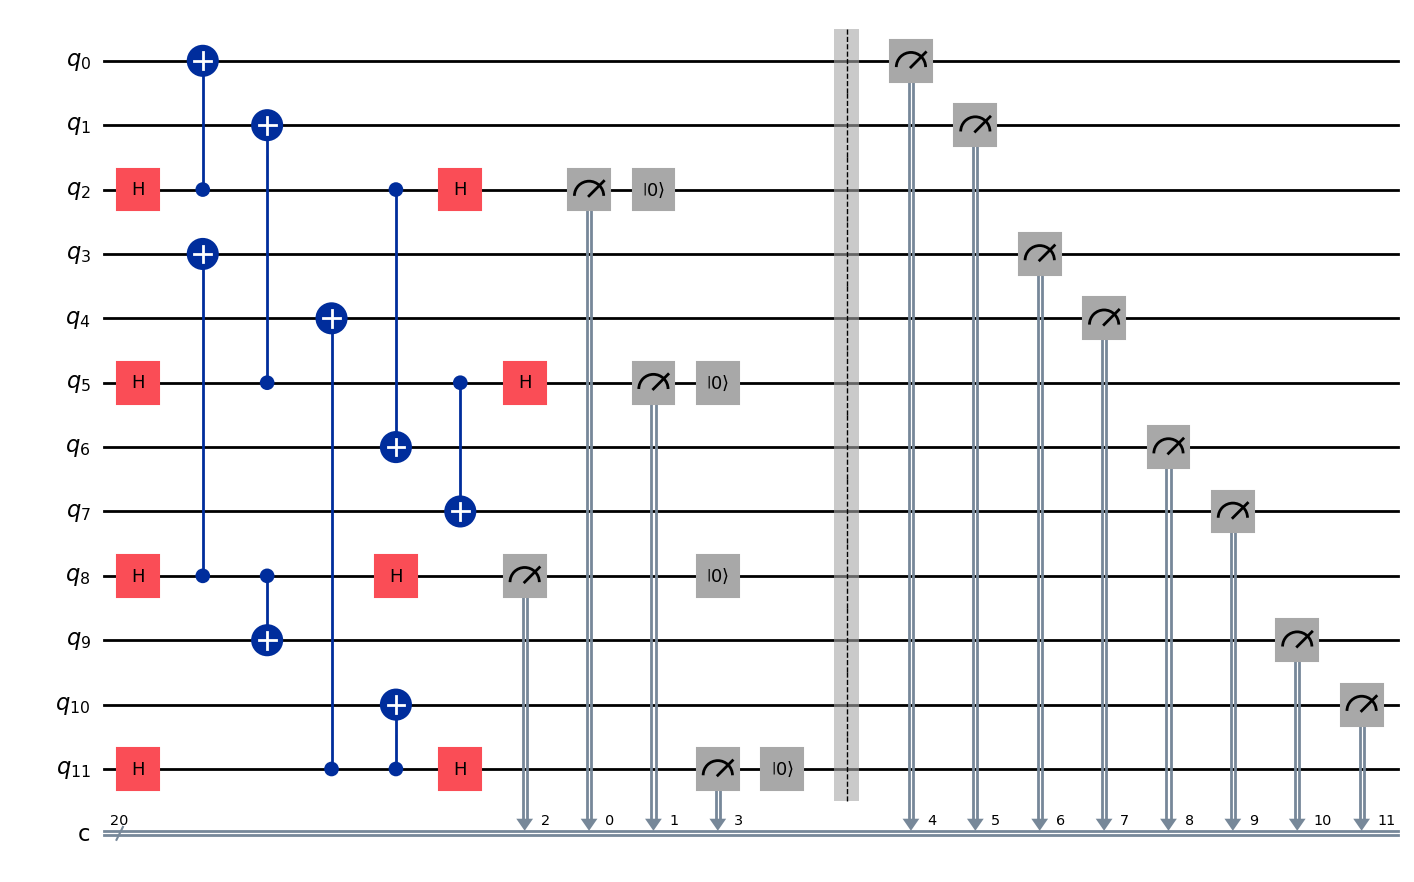

In [19]:
polar_n3_z_meas_data = polar_code_p2(3, True, "z", True)
polar_n3_z_meas_data.draw("mpl", fold=-1)

For this code length, as it is started with two one's (ZZ measurement) at the beginning, it will give the result close to 100% of preparation rate. So, for both cases before and after will be a little difference. But, applying the simplification will reduce the number of gates (CNOT, measurement and reset)

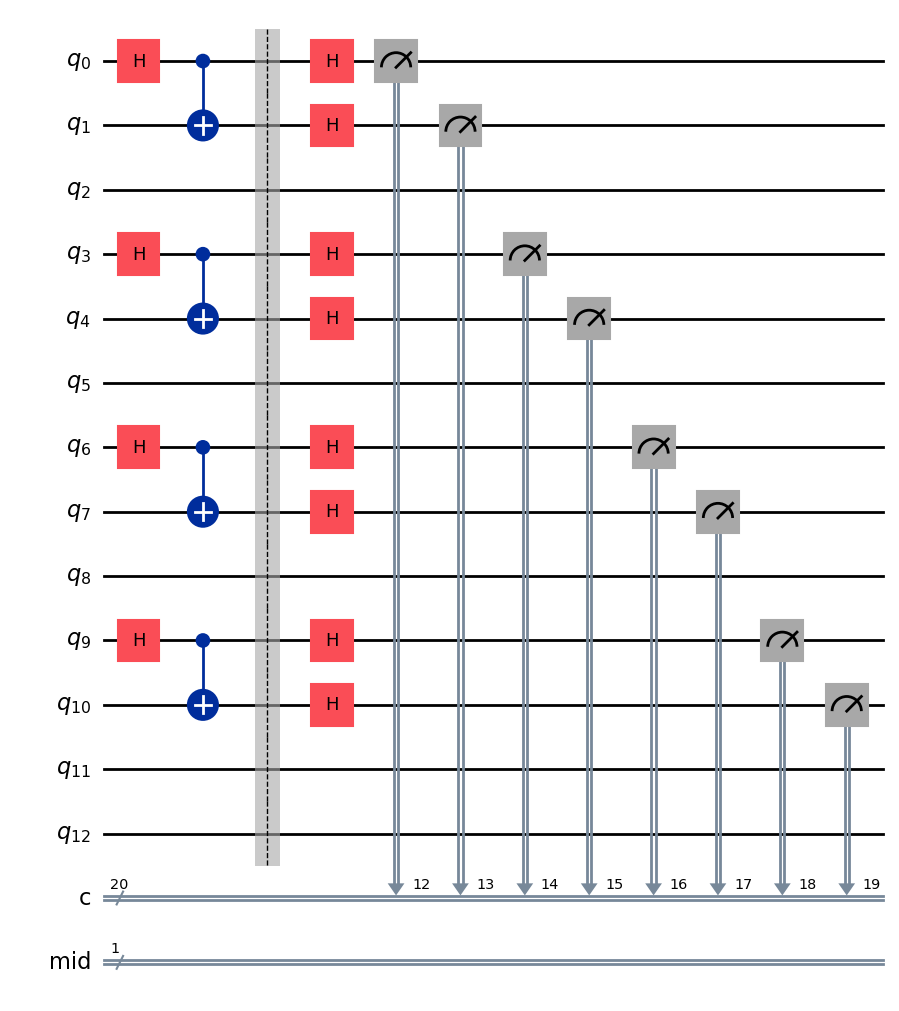

In [20]:
qreg = QuantumRegister(13, name="q")
creg = ClassicalRegister(20, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(4):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])


qc.barrier()

qc = qc.decompose()

m_idx = 12
for i in range(12):
    if i in [2,5,8,11]:
        continue

    qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1

qc_h1 = qc
qc_h1.draw("mpl", fold=-1)

#### Metric: Number of Operations

In [21]:
polar_n3_z_meas_data.count_ops()

OrderedDict([('measure', 12),
             ('h', 8),
             ('cx', 8),
             ('reset', 4),
             ('barrier', 1)])

In [22]:
qc_h1.count_ops()

OrderedDict([('h', 12), ('measure', 8), ('cx', 4), ('barrier', 1)])

With the technique above, we will save:
- 4 measure gates
- 4 cnot gates
- 4 reset gates
- 4 hadamard gates

### $n=3$, $i=4$ for logical $|+\rangle$, b = 010

Here we have a circuit for Q1 State Preparation Quantum Polar Code with $n=3$, $i=4$ for logical $|+\rangle$

n = 3 , b = 010 (2) , i = 3


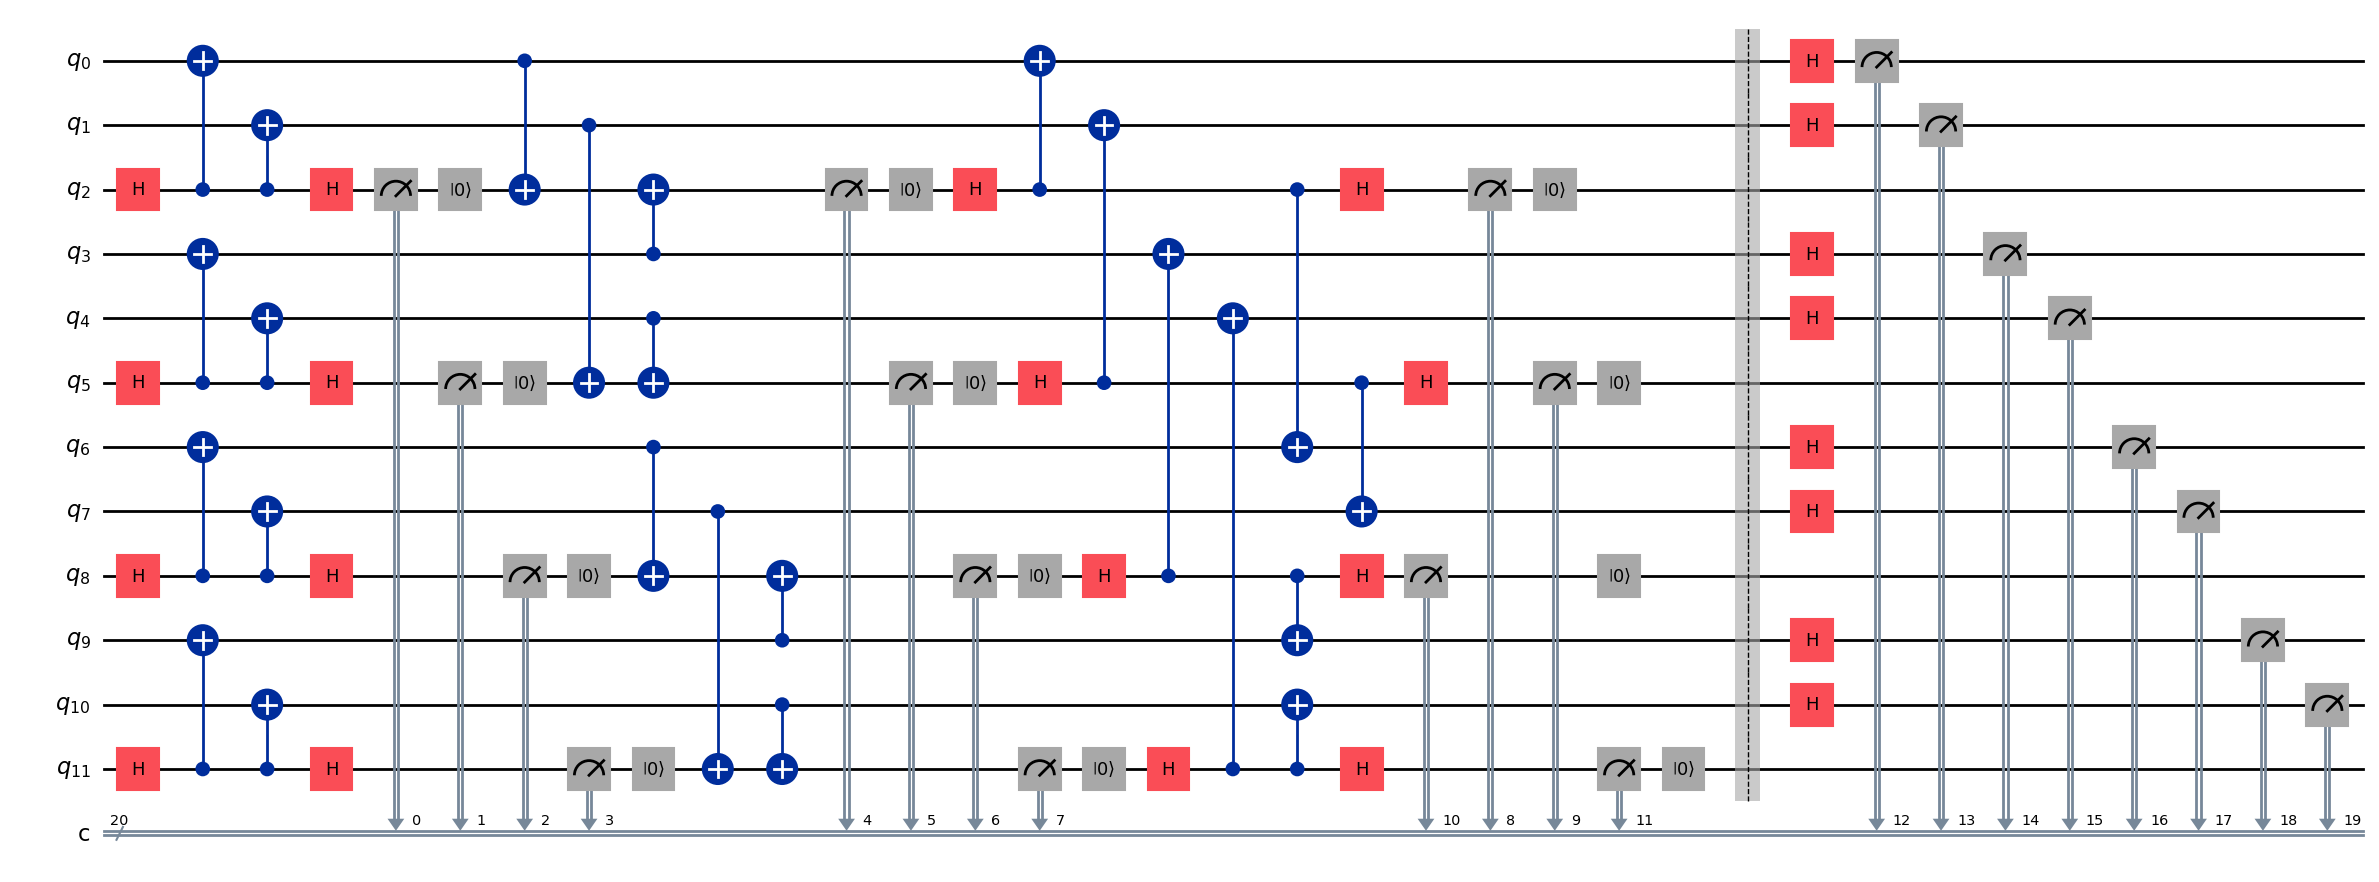

In [23]:
polar_n3_x_meas_data = polar_code_p2(3, True, "x", True)
polar_n3_x_meas_data.draw("mpl", fold=-1)

After applying the simplification, it will become:

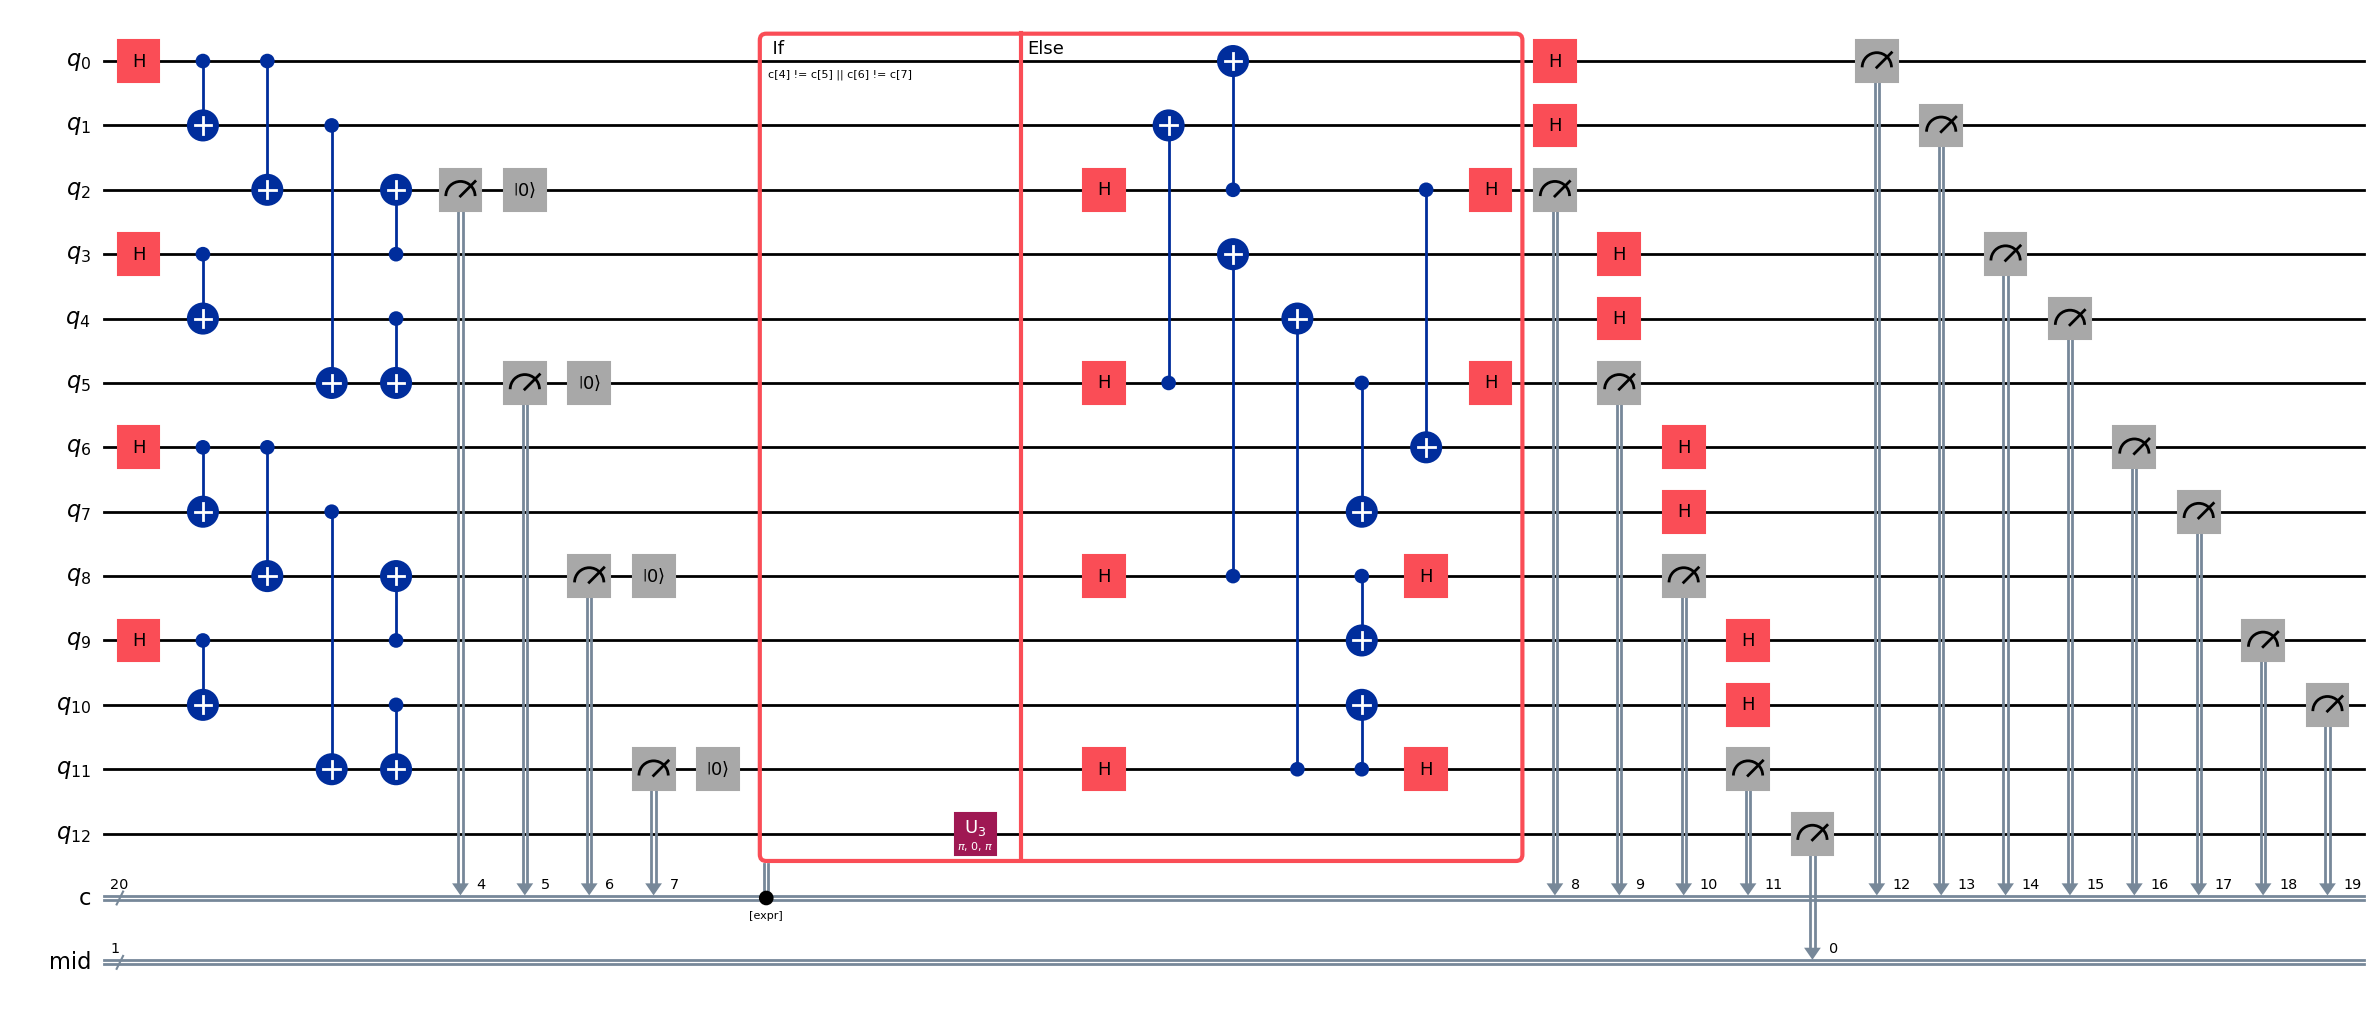

In [24]:
qreg = QuantumRegister(13, name="q")
creg = ClassicalRegister(20, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(4):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(2):
    start = i * 6 
    qc.append(qc_z2, range(start, start + 6), range(2))


m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    qc.reset(i)
    m_idx = m_idx + 1

# qc.barrier()

expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
with qc.if_test(expr_1) as else_:
    qc.x(12)
with else_:
    # qc.append(qc_z3, range(12), [8,9,10,11])
    qc.append(qc_x3, range(12), [8,9,10,11])

qc.measure(12, mid)

# m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    # qc.reset(i)
    m_idx = m_idx + 1

qc = qc.decompose()

# qc.barrier()

m_idx = 12
for i in range(12):
    if i in [2,5,8,11]:
        continue

    qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1

qc_h1 = qc
qc_h1.draw("mpl", fold=-1)

#### Metric: Number of Operations

In [25]:
polar_n3_x_meas_data.count_ops()

OrderedDict([('h', 24),
             ('cx', 24),
             ('measure', 20),
             ('reset', 12),
             ('barrier', 1)])

In [26]:
qc_h1.count_ops()

OrderedDict([('measure', 17),
             ('h', 12),
             ('cx', 12),
             ('reset', 4),
             ('if_else', 1)])

If an error is detected at the second layer, in total it will have less:
- 8 hadamard gates
- 8 CNOT gates
- 3 measure gates
- 4 reset gates

However, the current problem is the current technology of mid-circuit measurement and feed-forward operation is costly and takes a lot of time. 

Hopefully soon IBM will upgrade their Quantum Processor with the new Dynamic Circuit (https://docs.quantum.ibm.com/announcements/service-alerts/2025-05-25-dynamic-circuits-upgrade) which will be 75x faster and less noisy.

#### Metric: Quantum Resource (Simulation)

In [27]:
def run_simulation_n3(qc, shots, sim, seed_simulator):
    tqc = pm.run(qc)
    tmp_start_time  = time.perf_counter()
    result = sim.run(tqc, shots = shots, seed_simulator=seed_simulator).result()
    tmp_end_time = time.perf_counter()
    sim_time = tmp_end_time - tmp_start_time
    print("Simulation time: {} seconds".format(sim_time))

    count = result.get_counts()
    
    return count, sim_time
    
def get_layers_n3(count):

    layers = []
    layer_1 = {}
    layer_2 = {}
    layer_3 = {}
    layer_mid = {}
    for key, value in count.items():
        key = key.lstrip()

        l1 = key[-4:]
        l2 = key[-8:-4]
        l3 = key[-12:-8]
        lm = key[0]

        if l1 not in layer_1:
            layer_1[l1] = value
        else:
            layer_1[l1] = layer_1[l1] + value

        if l2 not in layer_2:
            layer_2[l2] = value
        else:
            layer_2[l2] = layer_2[l2] + value

        if l3 not in layer_3:
            layer_3[l3] = value
        else:
            layer_3[l3] = layer_3[l3] + value

        if lm not in layer_mid:
            layer_mid[lm] = value
        else:
            layer_mid[lm] = layer_mid[lm] + value

    layers.append(layer_1)
    layers.append(layer_2)
    layers.append(layer_3)
    layers.append(layer_mid)

    return layers

In [28]:
seed_simulator = randint(1, 9999999)
shots = 50
seed_simulator

3382500

In [29]:
# res_normal_ideal = run_simulation_n3(polar_n3_x_meas_data, shots, sim_ideal, seed_simulator)
# res_h1_ideal = run_simulation_n3(qc_h1, shots, sim_ideal, seed_simulator)

In [30]:
# res_normal_noisy = run_simulation_n3(polar_n3_x_meas_data, shots, sim_noisy, seed_simulator)
# res_h1_noisy = run_simulation_n3(qc_h1, shots, sim_noisy, seed_simulator)

##### Run to real backend

In [31]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n3_x_meas_data)
# tqc_2 = pm.run(qc_h1)

# pubs_1 = [tqc_1]
# pubs_2 = [tqc_2]

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
#              )
# sampler = Sampler(mode=backend, options=options) 
# job = sampler.run(pubs_1)
# print(job.job_id(), hw_name)

# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)



In [32]:
# d1anhb55z6q0008pg7p0 ibm_sherbrooke -> normal (14s), 606, 0.5016
# d1anhcxn2txg008e5xsg ibm_sherbrooke -> with dynamic circuit (10s), 1661, 0.4936

# d1ansk6n2txg008e60r0 ibm_sherbrooke -> normal (14s)
# d1anxgyn2txg008e6310 ibm_sherbrooke -> with dynamic circuit (10s)

# d1cnsadmya70008njs00 ibm_sherbrooke -> normal (14s) # chores.acetone-0t@icloud.com
# d1cnsaxqf56g00803kn0 ibm_sherbrooke -> with dynamic circuit (10) # chores.acetone-0t@icloud.com

In [33]:
job_normal = service.job("d1cnsadmya70008njs00")

result = job_normal.result()
res_1 = result[0].data.c.get_counts()

n = 3
lstate = "X"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)


In [34]:
def update_count_dict_n3_t2_discard(count_ideal):
    creg_counts = {}
    total_discard = 0
    for key, value in count_ideal.items():
        key = key.replace(" ", "")  # remove spaces, just in case
        creg_part = key[-20:]
        mid_part = key[0]
        
        if "1" in mid_part:
            total_discard = total_discard + value
            continue

        creg_counts[creg_part] = creg_counts.get(creg_part, 0) + value

    print("Total discarded :", total_discard)
    return creg_counts


In [35]:
job_h1 = service.job("d1cnsaxqf56g00803kn0")

result_h1 = job_h1.result()
res_1 = result_h1[0].join_data().get_counts()

tmp_start_time  = time.perf_counter()
creg_counts = update_count_dict_n3_t2_discard(res_1)
tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time
count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)


Total discarded : 2072


In [36]:
print("time old : ", detect_normal + decoding_normal)
print("time new : ", detect_h1 + decoding_h1 + dec_filter_time)

time old :  0.21160323100048117
time new :  0.15730720599822234


In [37]:
print("old :", count_accept / shots, ler)
print("M1 :", count_accept_h1 / shots, ler_h1)

print("Count accept : ", count_accept, count_accept_h1)
print("Count logerror : ", count_logerror, count_logerror_h1)
print("Count undecided : ", count_undecided, count_undecided_h1)

print("Time detect : ", detect_normal, detect_h1)
print("Time decoding : ", decoding_normal, decoding_h1)

old : 13.36 0.5
M1 : 29.9 0.49765886287625416
Count accept :  668 1495
Count logerror :  334 751
Count undecided :  565 1306
Time detect :  0.1932872569996107 0.12263519699990866
Time decoding :  0.018315974000870483 0.03401358100018115


In [38]:
# old : 0.1212 0.5016501650165016
# M1 : 0.3328 0.49399038461538464
# Count accept :  606 1664
# Count logerror :  302 842
# Count undecided :  531 1531
# Time detect :  0.22877241400055937 0.20858470099847182
# Time decoding :  -0.005671039001754252 0.024920874002418714

In [39]:
# Time needed

result_h1[0].data.mid.get_counts()

{'1': 2072, '0': 2928}

### $n=4$, $i=7$ for logical $|0\rangle$, b = 0110

Here we have a circuit for Q1 State Preparation Quantum Polar Code with $n=3$, $i=4$ for logical $|0\rangle$, b = 0110

n = 4 , b = 0110 (6) , i = 7


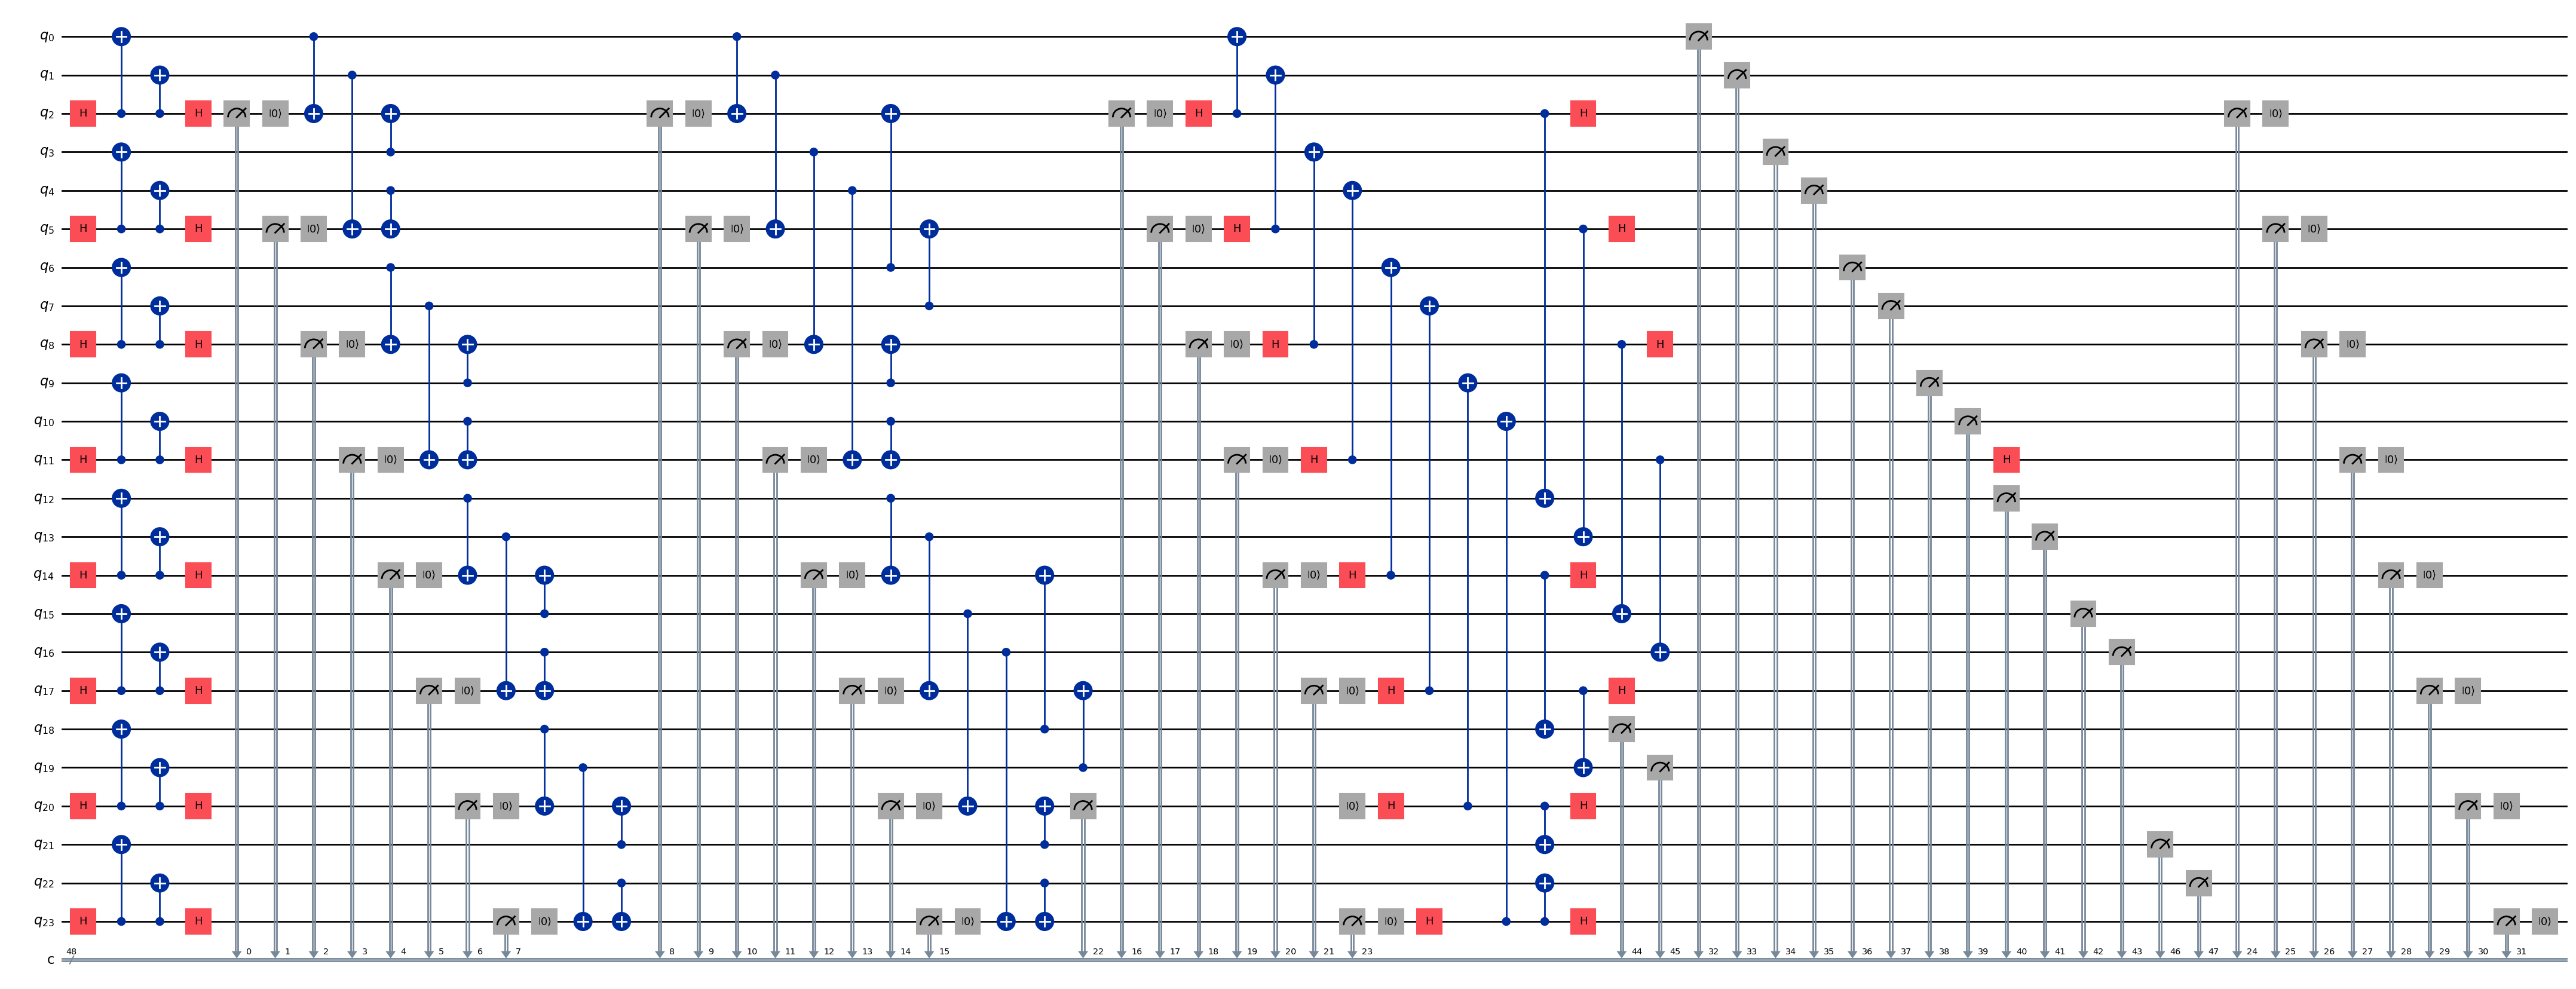

In [40]:
polar_n4_z_meas_data = polar_code_p2(4, True, "z", False)
polar_n4_z_meas_data.draw("mpl", fold=-1)

Applying the simplification it will become:

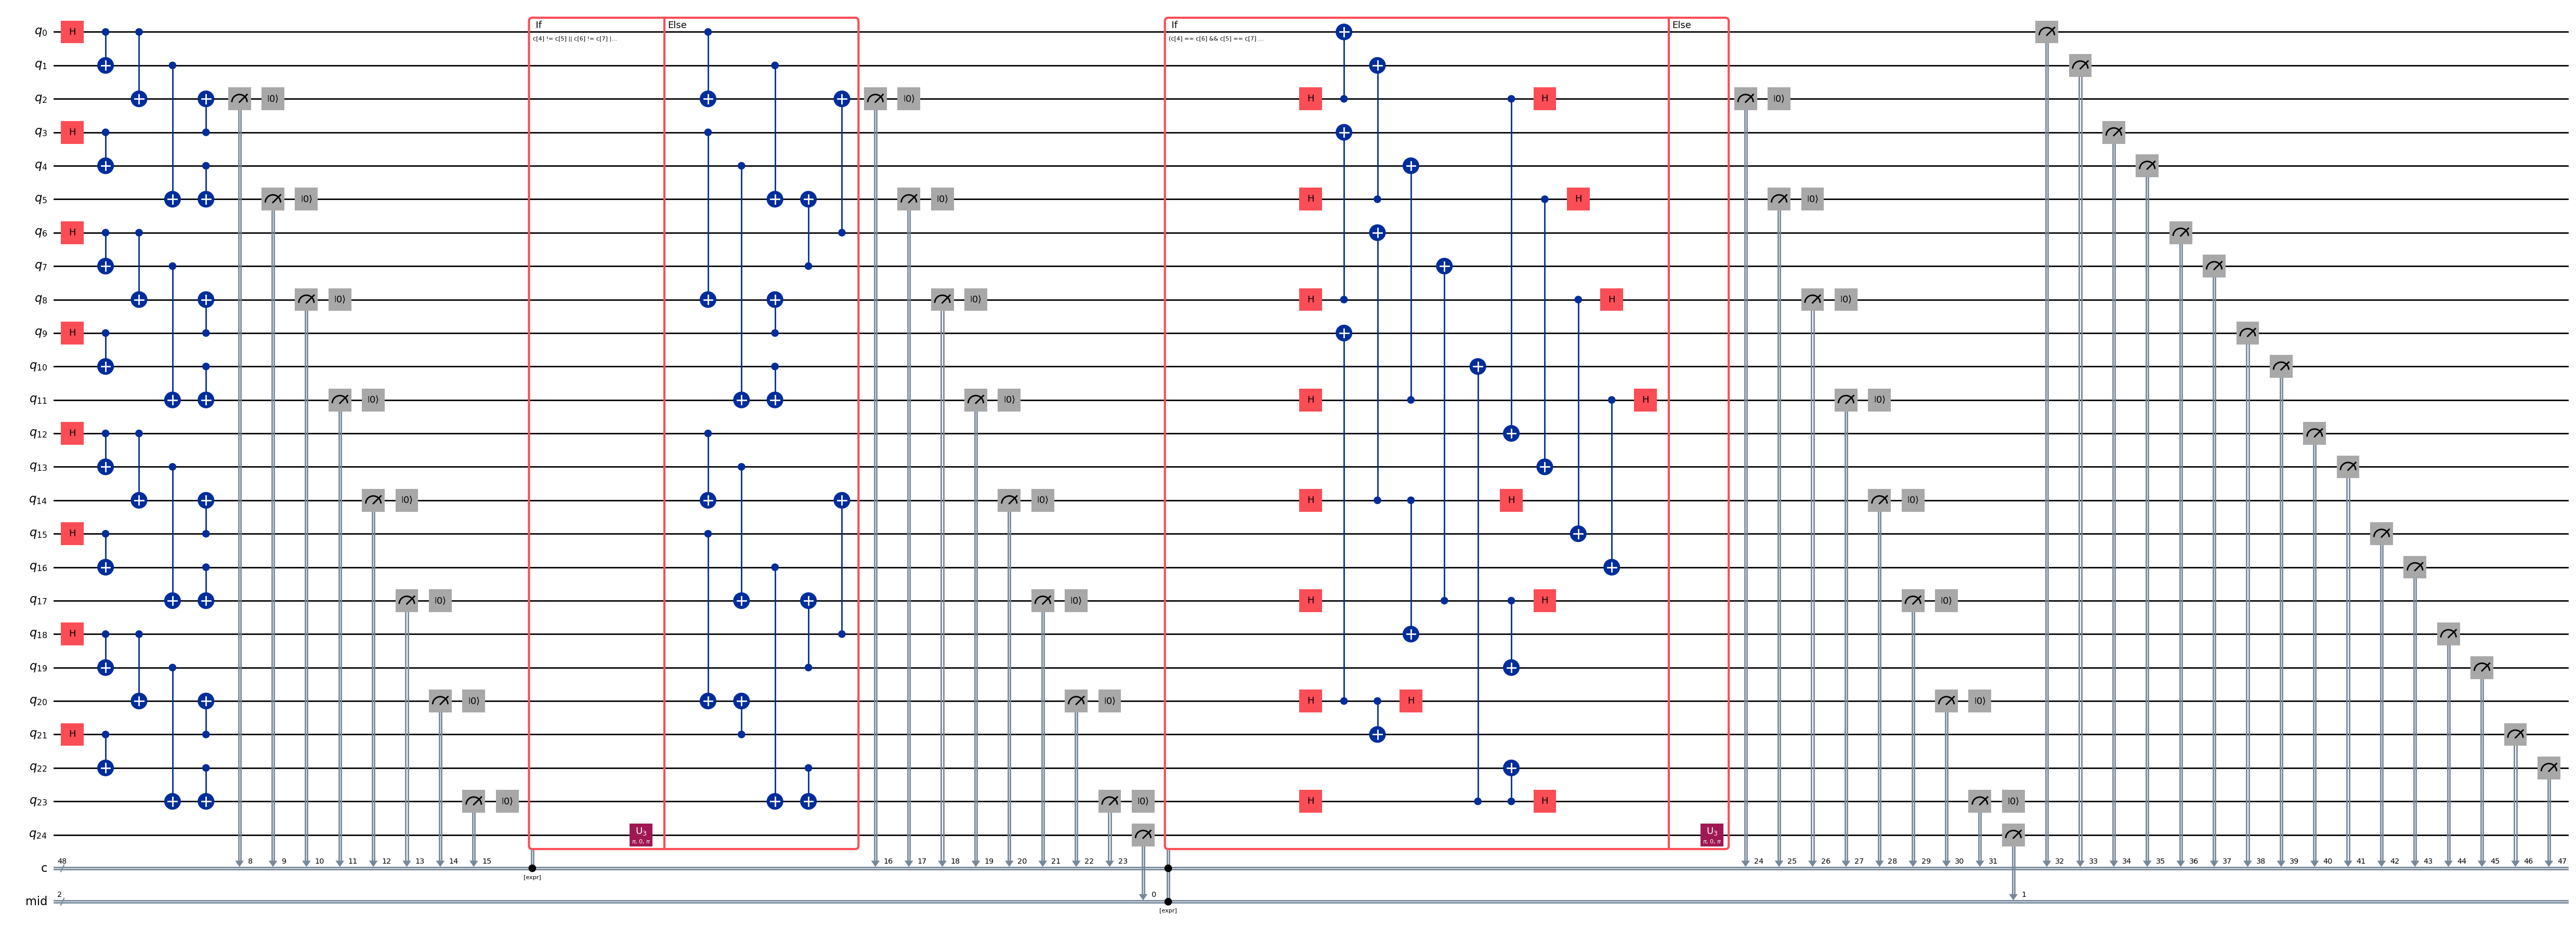

In [41]:
qreg = QuantumRegister(25, name="q")
creg = ClassicalRegister(48, name="c")
mid = ClassicalRegister(2, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(8):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(4):
    start = i * 6
    qubits = range(start, start + 6)       
    clbits = range(2 * i + 4, 2 * i + 6)  
    qc.append(qc_z2, qubits, clbits)

m_idx = 8
for offset, qb in enumerate(range(2, 24, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

# expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
expr_1 = expr.logic_or(
expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) ),
expr.logic_or( expr.not_equal(creg[8], creg[9]), expr.not_equal(creg[10], creg[11]) )
)
with qc.if_test(expr_1) as else_:
    qc.x(24)

with else_:

    for i in range(2):    
        start = i * 12
        qubits = range(start, start + 12)
        clbits = range(4)
        qc.append(qc_z3, qubits, clbits)

qc.measure(24, mid[0])

for offset, qb in enumerate(range(2, 24, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

expr_2 = expr.logic_and( 
            expr.logic_or( 
            expr.logic_and(
            expr.logic_and(expr.equal(creg[4], creg[6]) , expr.equal(creg[5], creg[7])),
            expr.logic_and(expr.equal(creg[8], creg[10]) , expr.equal(creg[9], creg[11])) 
            ),
            expr.logic_and(
            expr.logic_and(expr.not_equal(creg[4], creg[6]) , expr.not_equal(creg[5], creg[7])),
            expr.logic_and(expr.not_equal(creg[8], creg[10]) , expr.not_equal(creg[9], creg[11])) 
            )
           ),
        expr.equal(mid, 0b00)
        )
    
with qc.if_test(expr_2) as else_:
    qc.append(qc_x4, range(24), range(8))

with else_:
    qc.x(24)

qc.measure(24, mid[1])

for offset, qb in enumerate(range(2, 24, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

qc = qc.decompose()

for i in (j for j in range(24) if j % 3 != 2):
    qc.measure(i, m_idx)
    m_idx += 1

qc_h1 = qc
qc_h1.draw("mpl", fold=-1)

#### Metric: Number of Operations

In [42]:
polar_n4_z_meas_data.count_ops()

OrderedDict([('cx', 64), ('measure', 48), ('h', 32), ('reset', 32)])

In [43]:
qc_h1.count_ops()

OrderedDict([('measure', 42),
             ('cx', 24),
             ('reset', 24),
             ('h', 8),
             ('if_else', 2)])

If an error is detected at the second layer, in total it will have less:
- 24 hadamard gates
- 40 CNOT gates
- 6 measure gates
- 8 reset gates

#### Metric: Quantum Resources

In [44]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n4_z_meas_data)
# tqc_2 = pm.run(qc_h1)

# pubs_1 = [tqc_1]
# pubs_2 = [tqc_2]

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
#              )
# sampler = Sampler(mode=backend, options=options) 
# job = sampler.run(pubs_1)
# print(job.job_id(), hw_name)

# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)



In [45]:
# d1anyv35z6q0008pgd70 ibm_sherbrooke normal (32s)
# d1anywkv3z50008ab6vg ibm_sherbrooke dynamic (11s)

# d1ap65rv3z50008ab9pg ibm_sherbrooke normal (32s)
# d1ap670mya70008nb9rg ibm_sherbrooke dynamic (14s)

# d1apt3rqf56g008zwbd0 ibm_sherbrooke normal (31s)
# d1apt58mya70008nbeng ibm_sherbrooke normal (13s)

# d1b7k2c5z6q0008pkk40 ibm_sherbrooke normal (36s)

#------
# d1ar9vfmya70008nbpcg ibm_sherbrooke normal (33s)
# d1awj505z6q0008phhvg ibm_sherbrooke normal (33s)
# d1axhtqn2txg008e7k7g ibm_sherbrooke normal (33s)



In [46]:
def update_count_dict_n4_t2_discard(count_ideal):
    creg_counts = {}
    total_discard = 0
    for key, value in count_ideal.items():
        key = key.replace(" ", "")  # remove spaces, just in case
        creg_part = key[-48:]
        mid_part = key[:2]
        
        if "1" in mid_part:
            total_discard = total_discard + value
            continue

        creg_counts[creg_part] = creg_counts.get(creg_part, 0) + value

    print("Total discarded :", total_discard)
    return creg_counts


In [47]:
job_normal = service.job("d1apt3rqf56g008zwbd0")

result = job_normal.result()
res_1 = result[0].data.c.get_counts()

n = 4
lstate = "Z"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)

job_h1 = service.job("d1apt58mya70008nbeng")

result_h1 = job_h1.result()
res_1 = result_h1[0].join_data().get_counts()

tmp_start_time  = time.perf_counter()
creg_counts = update_count_dict_n4_t2_discard(res_1)
tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time

count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)


RuntimeJobNotFound: 'Job not found: d1apt3rqf56g008zwbd0'

In [48]:
print("time old : ", detect_normal + decoding_normal)
print("time new : ", detect_h1 + decoding_h1 + dec_filter_time)

time old :  0.21160323100048117
time new :  0.15730720599822234


In [49]:
result_h1[0].data.mid.get_counts()



{'1': 2072, '0': 2928}

In [50]:
print("old :", count_accept / shots, ler)
print("M1 :", count_accept_h1 / shots, ler_h1)

print("Count accept : ", count_accept, count_accept_h1)
print("Count logerror : ", count_logerror, count_logerror_h1)
print("Count undecided : ", count_undecided, count_undecided_h1)

print("Time detect : ", detect_normal, detect_h1)
print("Time decoding : ", decoding_normal, decoding_h1)

old : 13.36 0.5
M1 : 29.9 0.49765886287625416
Count accept :  668 1495
Count logerror :  334 751
Count undecided :  565 1306
Time detect :  0.1932872569996107 0.12263519699990866
Time decoding :  0.018315974000870483 0.03401358100018115


### $n=4$, $i=6$ for logical $|+\rangle$, b = 1010

n = 4 , b = 1010 (5) , i = 6


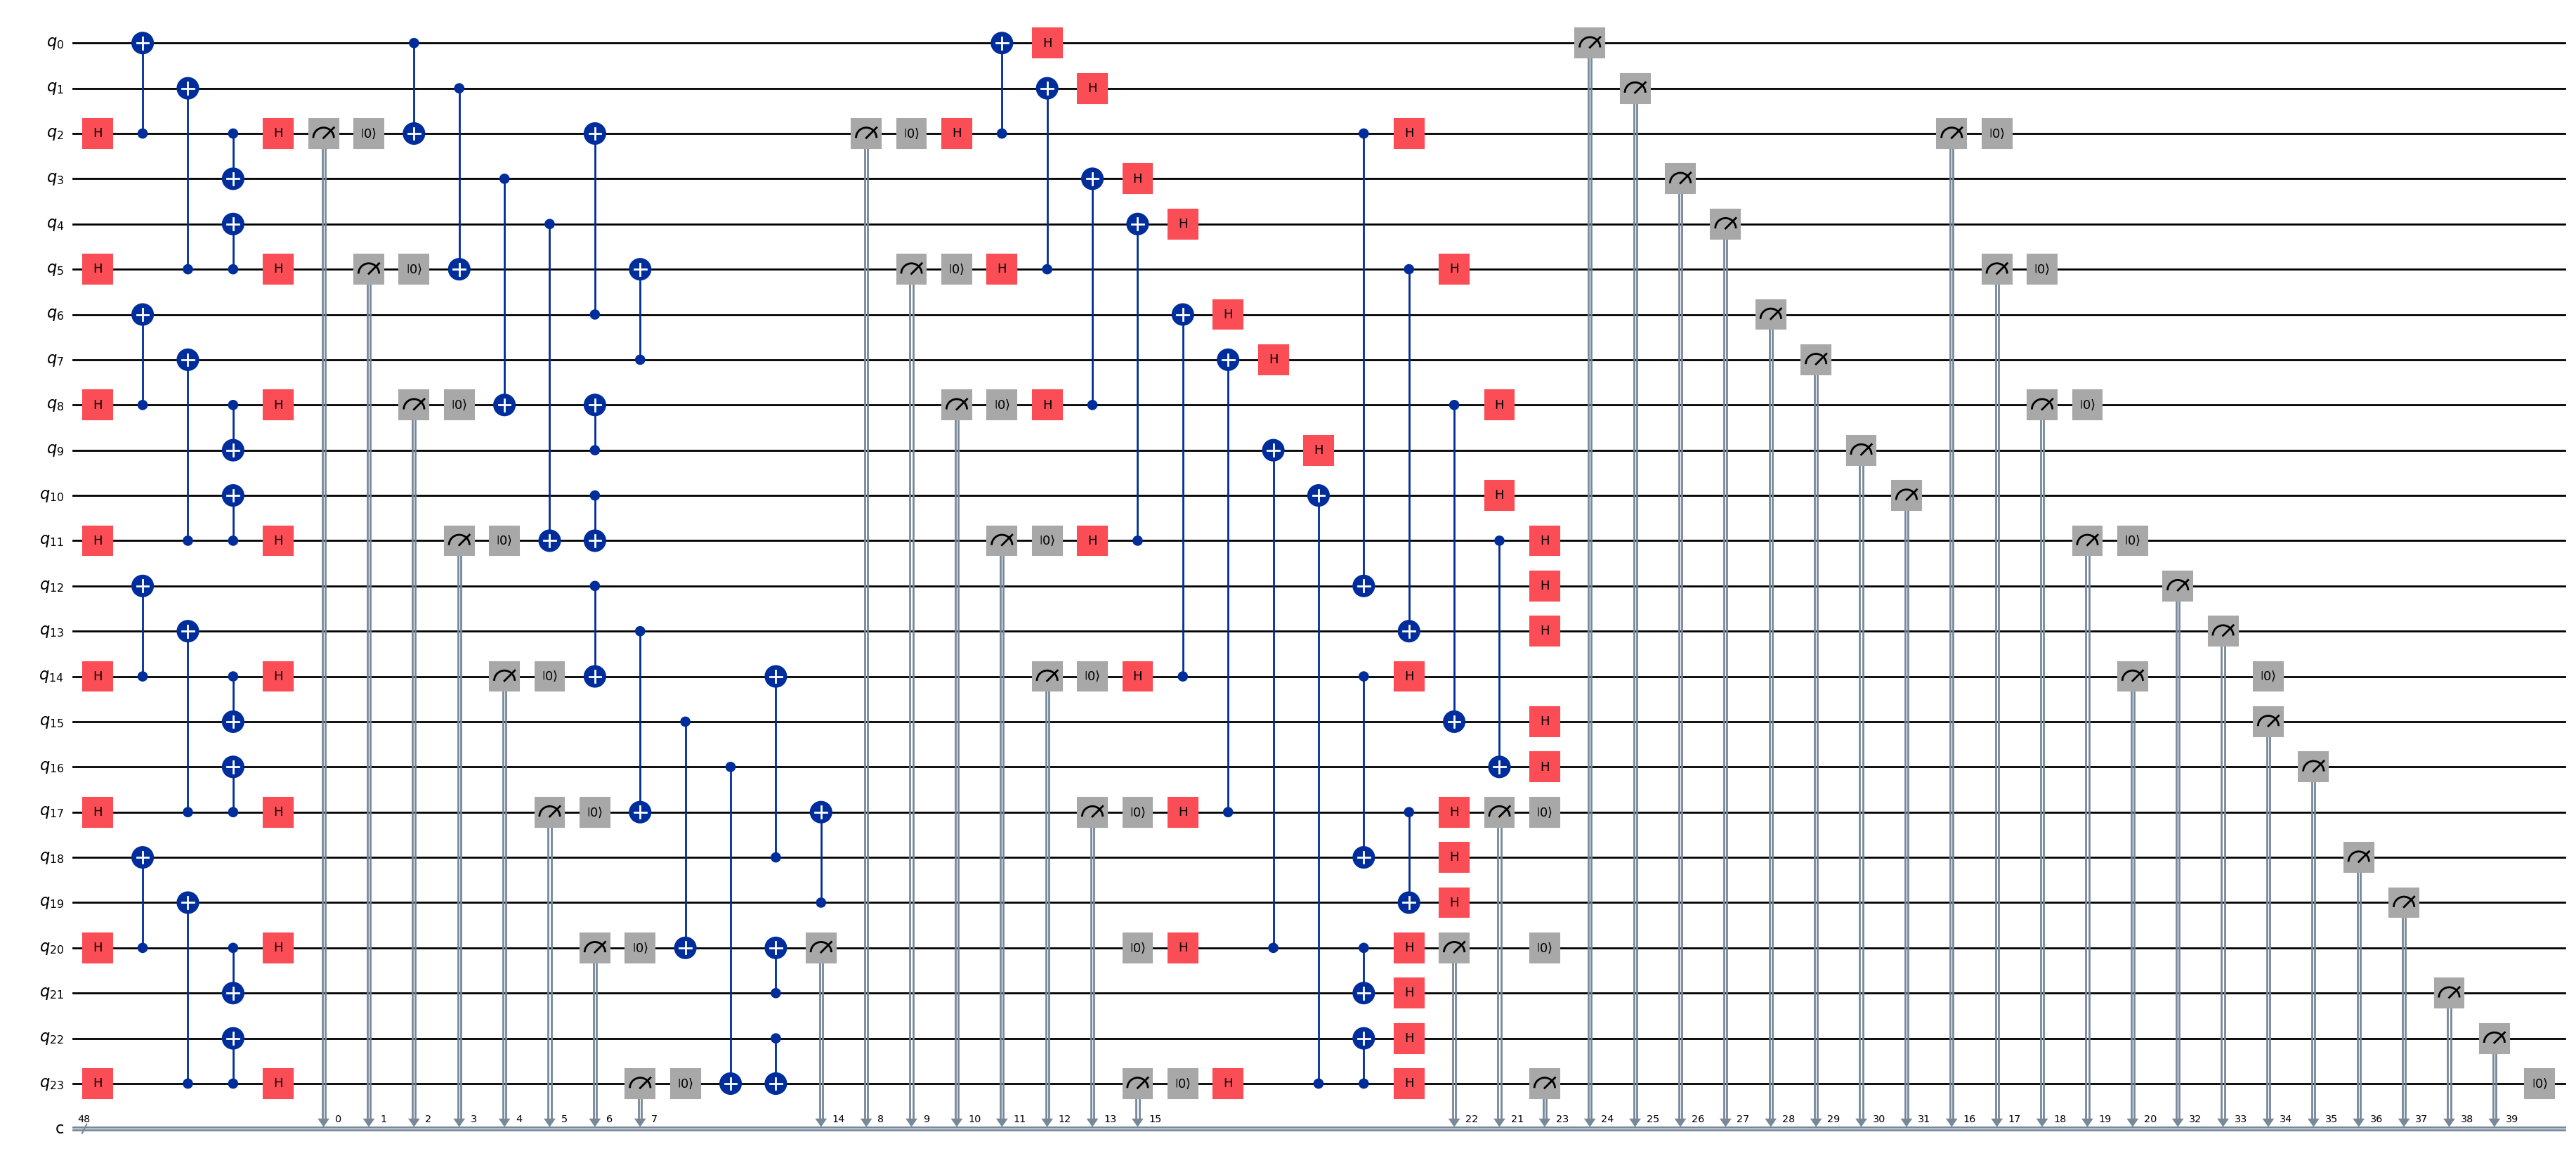

In [51]:
polar_n4_x_meas_data = polar_code_p2(4, True, "x", False)
polar_n4_x_meas_data.draw("mpl", fold=-1)

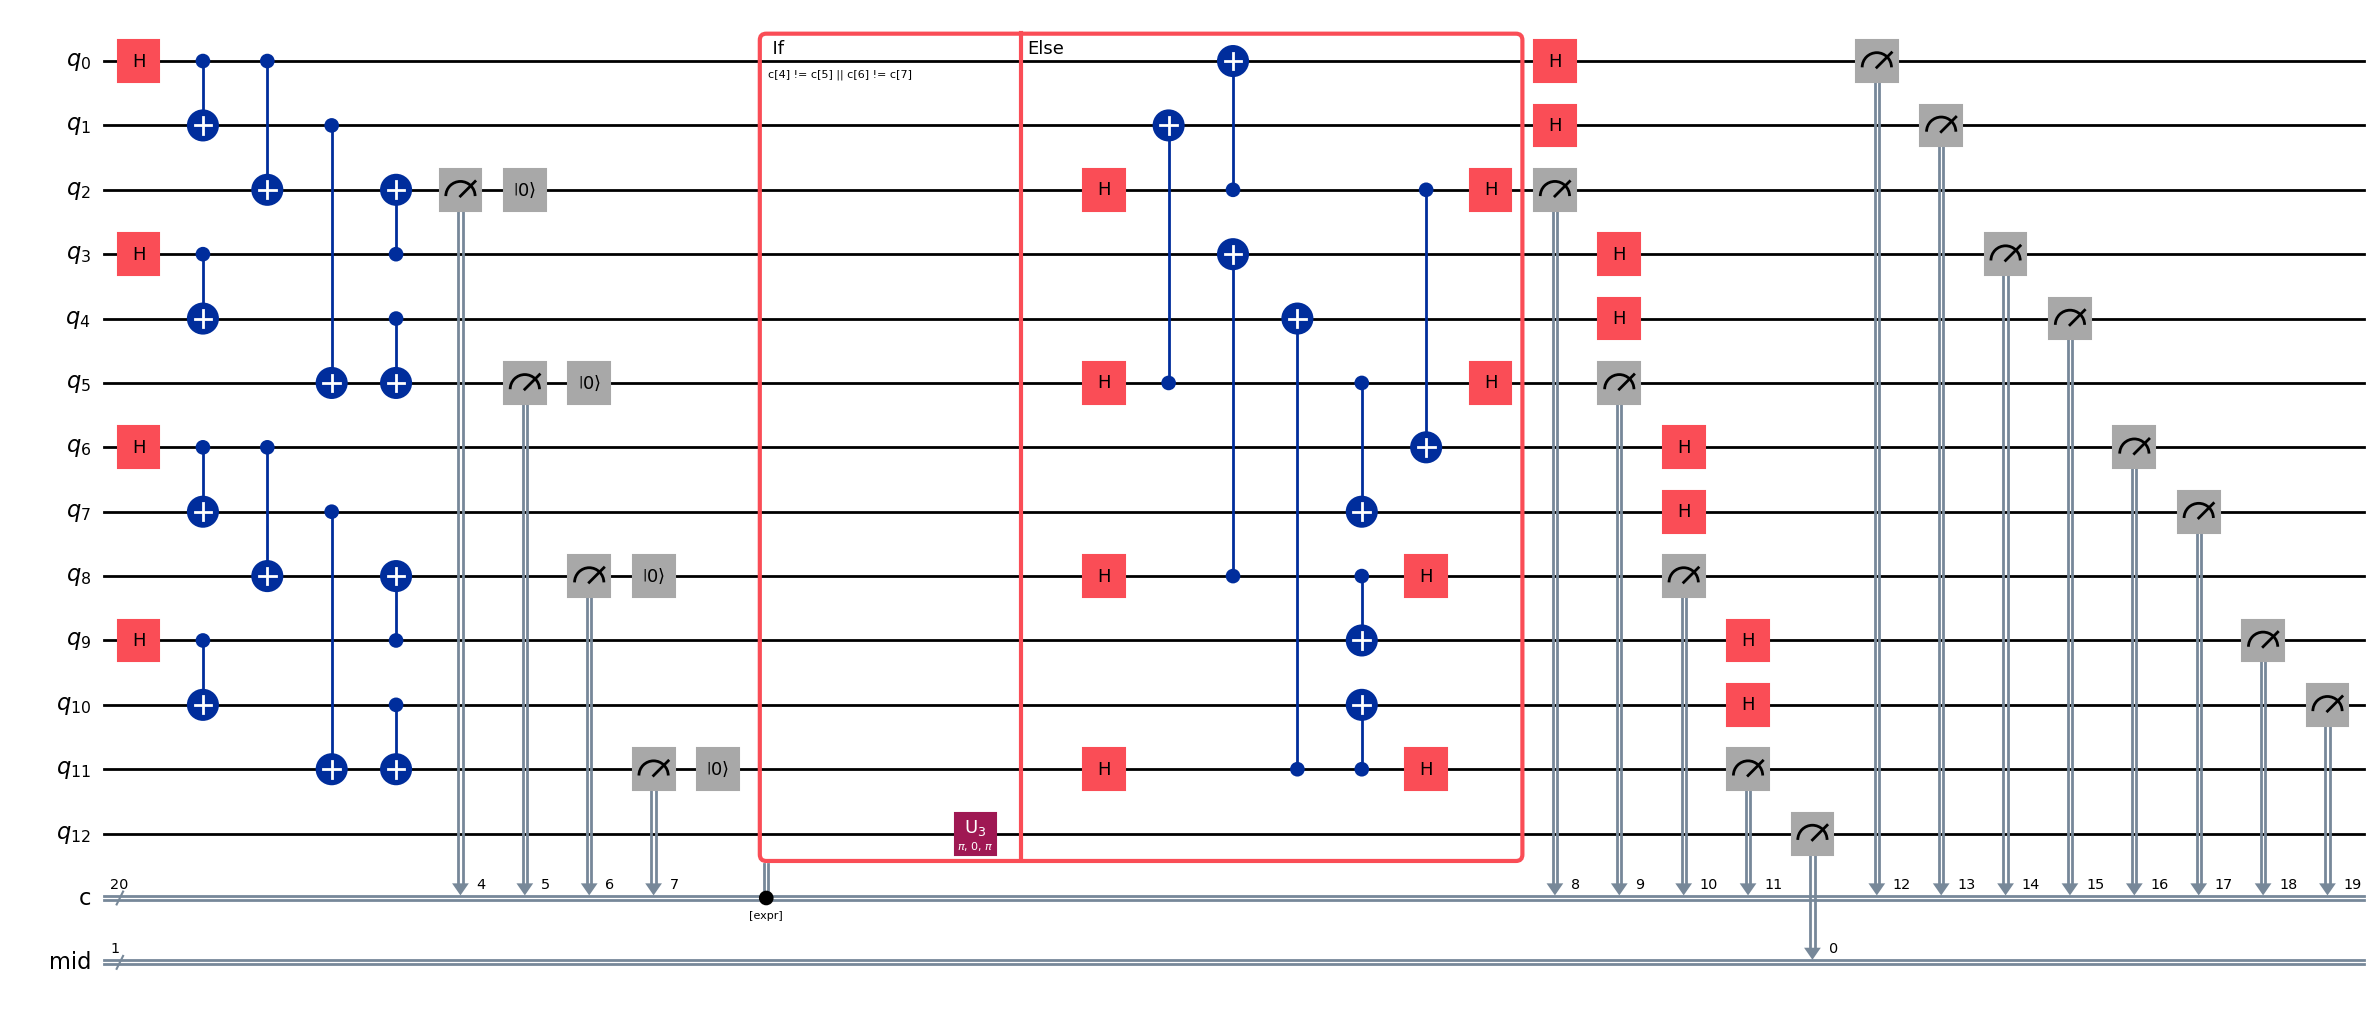

In [52]:
# n3 x 

qreg = QuantumRegister(13, name="q")
creg = ClassicalRegister(20, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(4):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(2):
    start = i * 6 
    qc.append(qc_z2, range(start, start + 6), range(2))

m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    qc.reset(i)
    m_idx = m_idx + 1

# qc.barrier()

expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
with qc.if_test(expr_1) as else_:
    qc.x(12)
with else_:
    # qc.append(qc_z3, range(12), [8,9,10,11])
    qc.append(qc_x3, range(12), [8,9,10,11])

qc.measure(12, mid)

# m_idx = 4
for i in [2,5,8,11]:
    qc.measure(i, m_idx )
    # qc.reset(i)
    m_idx = m_idx + 1

qc = qc.decompose()

# qc.barrier()

m_idx = 12
for i in range(12):
    if i in [2,5,8,11]:
        continue

    qc.h(i)
    qc.measure(i, m_idx)
    m_idx = m_idx + 1

qc_h1 = qc
qc_h1.draw("mpl", fold=-1)

In [53]:
# circ = polar_n3_x_meas_data
# circ_name = "n3_x"
# reps = 2
# compiled_circuits = multiprogram_compilation_qiskit([circ]*reps,backend)

# init_1 = compiled_circuits[0]["initial_layout"]
# init_2 = compiled_circuits[1]["initial_layout"]
# mc = merge_circuits(compiled_circuits, backend)

# used_qbts = []
# for i in init_1:
#     used_qbts.append(i)

# for i in init_2:
#     used_qbts.append(i)

# print(init_1)
# print(init_2)

# best_qubits = [72,122,108,91,70,123,26,124,40]
# # Combine init_1 and init_2 into used_qbts
# used_qbts = init_1 + init_2

# # Select up to 2 qubits from best_qubits that are not in used_qbts
# chosen_qubits = [q for q in best_qubits if q not in used_qbts][:2]

# # Add chosen qubits to used_qbts and distribute to init_1 and init_2
# used_qbts.extend(chosen_qubits)
# if len(chosen_qubits) == 2:
#     init_1.append(chosen_qubits[0])
#     init_2.append(chosen_qubits[1])

# # Optional: debugging prints
# print("Chosen:", chosen_qubits)
# print("Init 1:", init_1)
# print("Init 2:", init_2)

# pm_1 = generate_preset_pass_manager(
#     optimization_level=3, 
#     backend=backend,
#     initial_layout=init_1
# )

# pm_2 = generate_preset_pass_manager(
#     optimization_level=3, 
#     backend=backend,
#     initial_layout=init_2
# )

# tqc_h1_1 = pm_1.run(qc_h1)
# tqc_h1_2 = pm_2.run(qc_h1)

# tqc_h1_1.count_ops()


In [54]:
tqc_h1_1 = pm.run(qc_h1)
print(tqc_h1_1.count_ops())
print(get_initial_layout_from_circuit(tqc_h1_1))

# used_qbts = used_qubits(tqc_h1_1)
used_qbts = get_initial_layout_from_circuit(tqc_h1_1)

cm = backend.coupling_map
cm = build_idle_coupling_map(cm, used_qbts)

pm_3 = generate_preset_pass_manager(
        optimization_level=3, backend=backend, coupling_map=cm
    )
tqc_h1_2 = pm_3.run(qc_h1)

print(tqc_h1_2.count_ops())
print(used_qubits(tqc_h1_2))


OrderedDict({'rz': 110, 'sx': 58, 'ecr': 28, 'measure': 17, 'x': 9, 'reset': 4, 'if_else': 1})
[98, 91, 99, 100, 97, 79, 122, 121, 104, 106, 105, 111, 123]


/tmp/ipykernel_105506/2618568124.py:11: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm_3 = generate_preset_pass_manager(


OrderedDict({'rz': 114, 'sx': 58, 'ecr': 30, 'measure': 17, 'x': 6, 'reset': 4})
[9, 10, 11, 12, 13, 17, 107, 108, 112, 124, 125, 126]


#### Metric: Number of Operations


In [55]:
polar_n4_x_meas_data.count_ops()

OrderedDict([('h', 48), ('cx', 48), ('measure', 40), ('reset', 24)])

In [56]:
qc_h1.count_ops()

OrderedDict([('measure', 17),
             ('h', 12),
             ('cx', 12),
             ('reset', 4),
             ('if_else', 1)])

If error are detected at layer 2, it will save:
- 6 measure
- 24 cx gates
- 12 reset gates
- 24 h gates

#### Metric : Quantum Resource

In [57]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n4_x_meas_data)
# # tqc_h1_1 = pm_1.run(qc_h1)
# # tqc_h1_2 = pm_2.run(qc_h1)

# pubs_1 = [tqc_1]
# pubs_2 = [tqc_h1_1, tqc_h1_2]

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
                
#              )
# sampler = Sampler(mode=backend, options=options)
# job = sampler.run(pubs_1)
# print(job.job_id(), hw_name)

# # job = sampler.run(pubs_2)
# # print(job.job_id(), hw_name)



In [58]:
# d1bdppav3z50008af5yg ibm_sherbrooke normal (25s) chores.acetone-0t@icloud.com
# d1ar9wzqf56g008zwm20 ibm_sherbrooke dynamic (11s)

# d1bdq1mv3z50008af600 ibm_sherbrooke normal (25s) chores.acetone-0t@icloud.com
# d1awj60n2txg008e7880 ibm_sherbrooke dynamic (12s)

# d1bdq4cmya70008nf8b0 ibm_sherbrooke normal (24s) chores.acetone-0t@icloud.com
# d1axm1gmya70008ncngg ibm_sherbrooke dynamic (12s)


# d1b6tf1qf56g008zz4cg ibm_sherbrooke dynamic (10s)


In [59]:
job_normal = service.job("d1bdq4cmya70008nf8b0")

result = job_normal.result()
res_1 = result[0].data.c.get_counts()

n = 4
lstate = "X"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)


In [293]:
print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)

0 0 0 0 0.09673590499733109 0.0023305170034291223


In [71]:
def convert_dict_to_list(source_dict):
    result = []
    for key, value in source_dict.items():
        for i in range(value):
            result.append(key)

    return result

In [295]:
from qiskit.primitives import SamplerPubResult, PrimitiveResult

job_h1 = service.job("d1axm1gmya70008ncngg")

result: PrimitiveResult = job_h1.result()
res_1 = result[0].join_data().get_counts()
res_2 = result[1].join_data().get_counts()

list_res_1 = convert_dict_to_list(res_1)
list_res_2 = convert_dict_to_list(res_2)




RuntimeJobNotFound: 'Job not found: d1axm1gmya70008ncngg'

In [ ]:
from qiskit.primitives import SamplerPubResult, PrimitiveResult

res_pub:SamplerPubResult = result[0]

In [ ]:
n = 3
lstate = "X"

tmp_start_time  = time.perf_counter()
creg_counts_1 = update_count_dict_n3_t2_discard(res_1)
creg_counts_2 = update_count_dict_n3_t2_discard(res_2)
tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time


print(get_logical_error_on_accepted_states(n, lstate, creg_counts_1))
print(get_logical_error_on_accepted_states(n, lstate, creg_counts_2))


Total discarded : 2335
Total discarded : 112
(1298, 645, 1220, 0.5030816640986132, 0.1437509579991456, 0.02493629300079192)
(1928, 930, 1800, 0.5176348547717843, 0.14829549900241545, 0.020021278000058373)


In [296]:
list_clean_res_1 = convert_dict_to_list(creg_counts_1)
list_clean_res_2 = convert_dict_to_list(creg_counts_2)

In [297]:
len(list_clean_res_1), len(list_clean_res_2)

(2665, 4888)

In [298]:
final_combined_states = {}
clean_num = len(list_clean_res_1) if len(list_clean_res_1) < len(list_clean_res_2) else len(list_clean_res_2)

print(clean_num)
for idx in range(clean_num):
    keys = []

    keys.append(list_clean_res_1[idx])
    keys.append(list_clean_res_2[idx])

    new_key = ""
    for idx in range(20): # this is the number of measurement each circuit
        idx = idx + 1

        for key in keys:
            new_key =  key[-idx] + new_key

    if new_key in final_combined_states:
        final_combined_states[new_key] = final_combined_states[new_key] + 1
    else:
        final_combined_states[new_key] = 1

n = 4
lstate = "X"
count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, final_combined_states)

310/5000

2665


0.062

In [299]:
print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1)

635 303 556 0.5228346456692914 0.32830019399989396 0.03801170299993828


In [300]:
print("time old : ", detect_normal + decoding_normal)
print("time new : ", detect_h1 + decoding_h1 + dec_filter_time)

time old :  0.09906642200076021
time new :  0.368130974999076


In [301]:
print("old :", count_accept / shots, ler)
print("M1 :", count_accept_h1 / shots, ler_h1)

print("Count accept : ", count_accept, count_accept_h1)
print("Count logerror : ", count_logerror, count_logerror_h1)
print("Count undecided : ", count_undecided, count_undecided_h1)

print("Time detect : ", detect_normal, detect_h1)
print("Time decoding : ", decoding_normal, decoding_h1)

old : 0.0 0
M1 : 0.15875 0.5228346456692914
Count accept :  0 635
Count logerror :  0 303
Count undecided :  0 556
Time detect :  0.09673590499733109 0.32830019399989396
Time decoding :  0.0023305170034291223 0.03801170299993828


The result from the normal procedure doesn't have any accepted state. Means we cannot commpare the decoding time

### $n=5$, $i=8$ for logical $|0\rangle$, b = 11100

n = 5 , b = 11100 (7) , i = 8


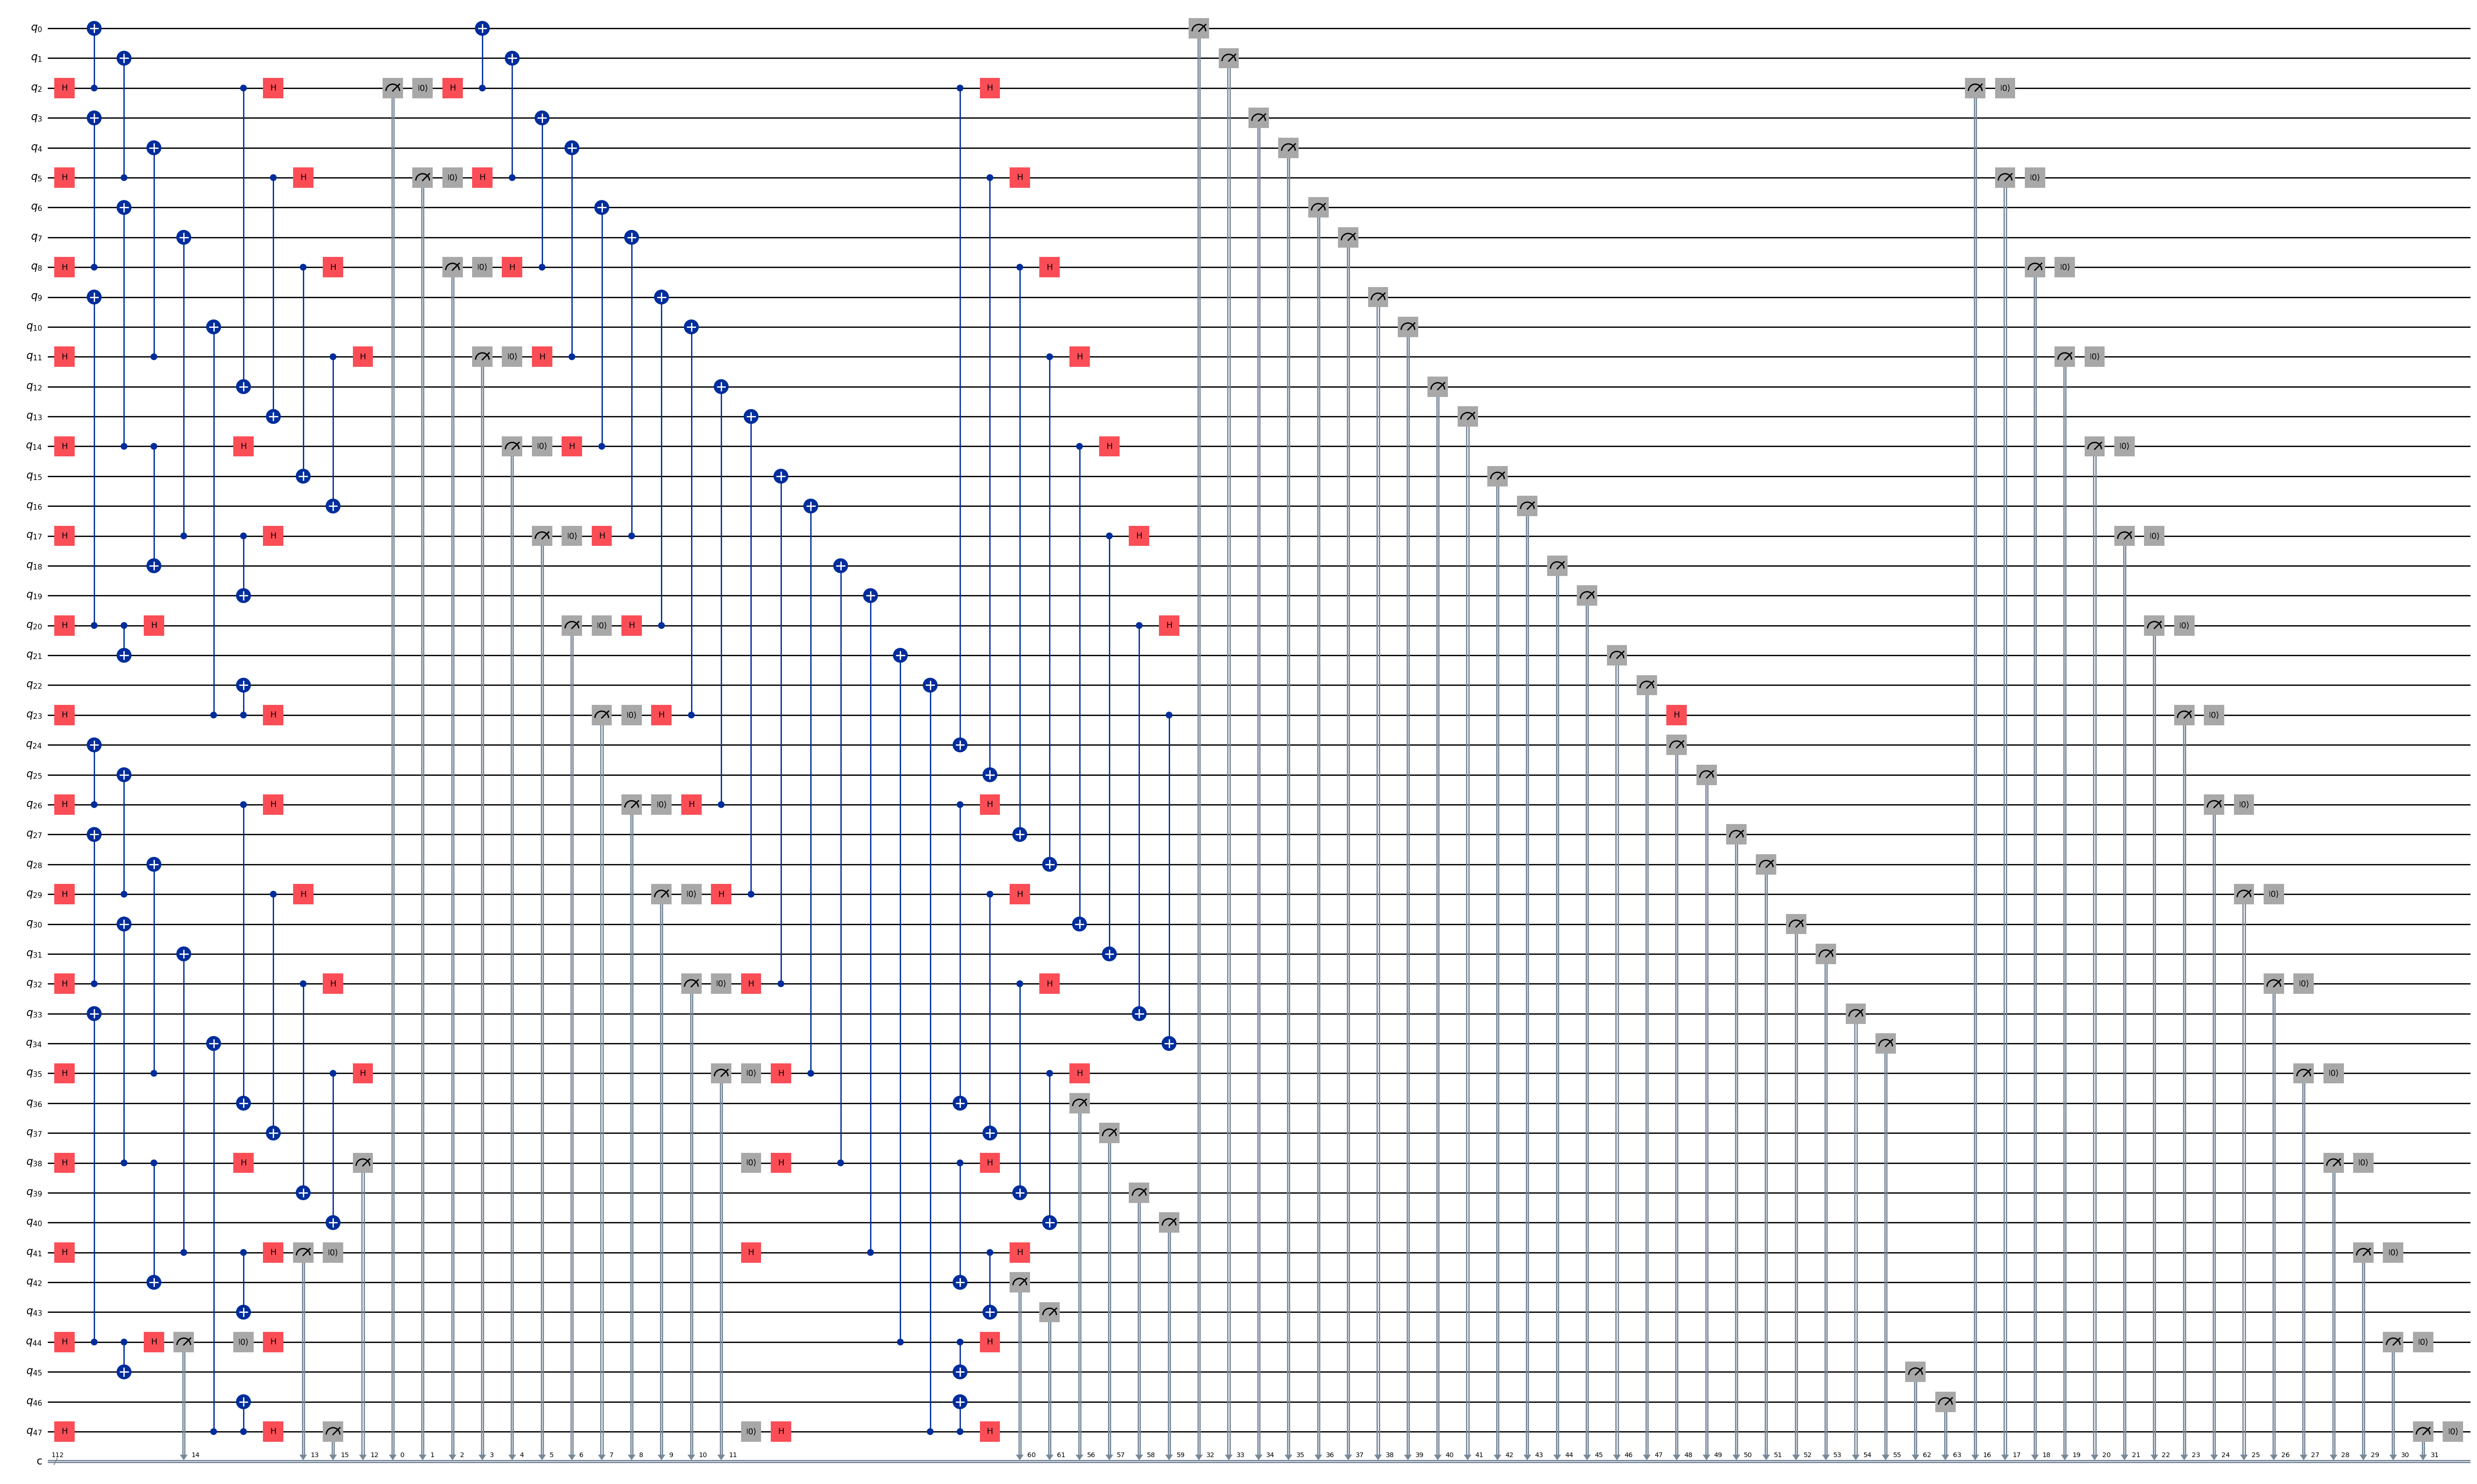

In [77]:
polar_n5_z_meas_data = polar_code_p2(5, True, "z", False)
polar_n5_z_meas_data.draw("mpl", fold=-1)

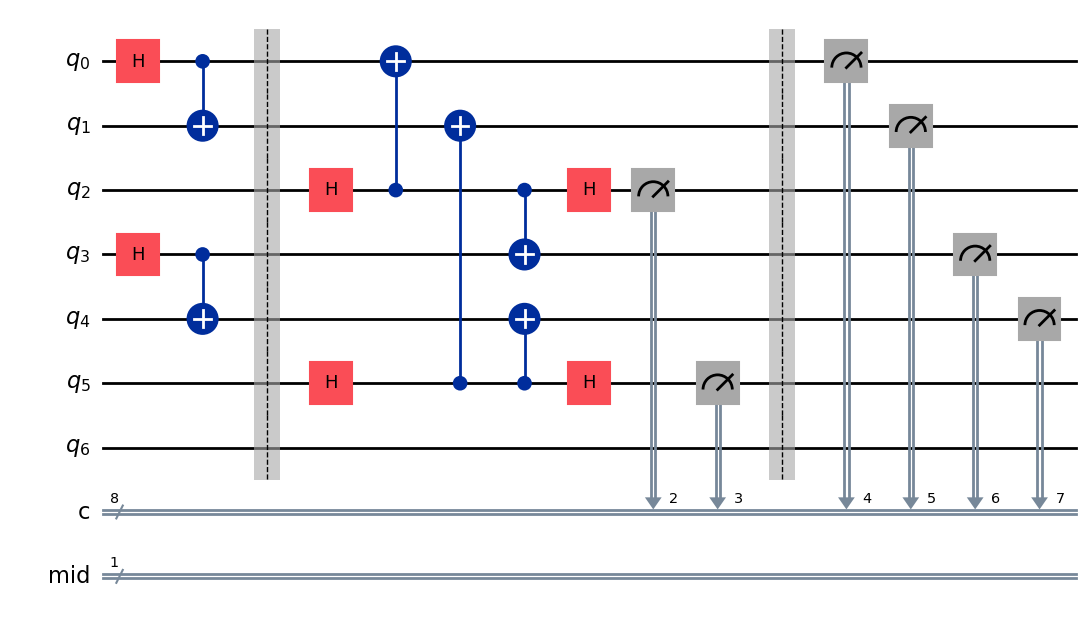

In [78]:
# 00

qreg = QuantumRegister(7, name="q")
creg = ClassicalRegister(8, name="c")
mid = ClassicalRegister(1, name="mid")
qc = QuantumCircuit(qreg,creg,mid)

for i in range(2):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

qc.barrier()

for i in range(1):
    start = i * 6 
    qc.append(qc_x2, range(start, start + 6), range(2))

m_idx = 2
for offset, qb in enumerate(range(2, 6, 3)): 
    qc.measure(qb, m_idx + offset)

m_idx += 2    

qc.barrier()

for i in (j for j in range(6) if j % 3 != 2):
    qc.measure(i, m_idx)
    m_idx += 1

qc_h1 = qc.decompose()
qc_h1.draw("mpl", fold=-1)

In [79]:
tqc = pm.run(qc_h1)
result = sim_ideal.run(tqc, shots = shots).result()
count = result.get_counts()
count


{'0 00110000': 291,
 '0 01101100': 309,
 '0 10011100': 290,
 '0 01010000': 342,
 '0 11001100': 308,
 '0 00111100': 311,
 '0 00000000': 323,
 '0 11110000': 324,
 '0 10010000': 304,
 '0 01100000': 312,
 '0 01011100': 333,
 '0 11111100': 307,
 '0 00001100': 312,
 '0 10101100': 329,
 '0 11000000': 306,
 '0 10100000': 299}

In [80]:
def get_layers_n2(count):

    layers = []
    layer_1 = {}
    layer_2 = {}
    layer_3 = {}
    layer_mid = {}
    for key, value in count.items():
        key = key.lstrip()

        l1 = key[-2:]
        l2 = key[-4:-2]
        l3 = key[-8:-4]
        lm = key[0]

        if l1 not in layer_1:
            layer_1[l1] = value
        else:
            layer_1[l1] = layer_1[l1] + value

        if l2 not in layer_2:
            layer_2[l2] = value
        else:
            layer_2[l2] = layer_2[l2] + value

        if l3 not in layer_3:
            layer_3[l3] = value
        else:
            layer_3[l3] = layer_3[l3] + value

        if lm not in layer_mid:
            layer_mid[lm] = value
        else:
            layer_mid[lm] = layer_mid[lm] + value

    layers.append(layer_1)
    layers.append(layer_2)
    layers.append(layer_3)
    layers.append(layer_mid)

    return layers

In [81]:
layers = get_layers_n2(count)

##### Metric: Number of Operations


In [82]:
polar_n5_z_meas_data.count_ops()

OrderedDict([('h', 64), ('cx', 64), ('measure', 64), ('reset', 32)])

In [83]:
qc_h1.count_ops()

OrderedDict([('h', 6), ('cx', 6), ('measure', 6), ('barrier', 2)])

Using the implementation above, we will have less:
- 16 hadamard gates
- 16 cnot gates
- 16 measured gates
- 16 reset gates

##### Metric : Quantum Resource

In [84]:
tqc_h1s = [] 

tmp = pm.run(qc_h1)
tqc_h1s.append(tmp)
print(tmp.count_ops())
# print(get_initial_layout_from_circuit(tmp))

used_qbts = get_initial_layout_from_circuit(tmp)

for i in range(7):

    # used_qbts = used_qubits(tqc_h1_1)
    

    cm = backend.coupling_map
    cm = build_idle_coupling_map(cm, used_qbts)

    pm_3 = generate_preset_pass_manager(
            optimization_level=3, backend=backend, coupling_map=cm
        )
    tmp = pm_3.run(qc_h1)
    tqc_h1s.append(tmp)

    # print(tmp.count_ops())
    # print(get_initial_layout_from_circuit(tmp))

    qbts = get_initial_layout_from_circuit(tmp)

    for q in qbts:
        used_qbts.append(q)

print(used_qbts)


OrderedDict({'rz': 41, 'sx': 18, 'ecr': 11, 'measure': 6, 'x': 4, 'barrier': 2})
[111, 104, 121, 123, 122, 105, 84, 126, 125, 107, 108, 112, 124, 0, 6, 5, 4, 3, 2, 1, 0, 86, 85, 106, 93, 87, 73, 0, 10, 11, 7, 16, 8, 9, 0, 103, 102, 101, 83, 82, 92, 0, 113, 114, 109, 116, 117, 115, 0, 118, 119, 99, 100, 110, 120, 0]


/tmp/ipykernel_105506/932293440.py:18: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm_3 = generate_preset_pass_manager(


In [85]:
len(tqc_h1s)

8

In [86]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.options import SamplerOptions

tqc_1 = pm.run(polar_n5_z_meas_data)
# tqc_h1_1 = pm_1.run(qc_h1)
# tqc_h1_2 = pm_2.run(qc_h1)

pubs_1 = [tqc_1]
pubs_2 = tqc_h1s

shots = 5000
options = SamplerOptions(
                default_shots=shots,
                # dynamical_decoupling=dd_options,
                # twirling= twirling_options
                
             )
sampler = Sampler(mode=backend, options=options)
job = sampler.run(pubs_1)
print(job.job_id(), hw_name)

job = sampler.run(pubs_2)
print(job.job_id(), hw_name)



/home/handy/Github/quantum_platform/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1102: UserWarning: The backend ibm_sherbrooke currently has a status of internal.
  warnings.warn(
/home/handy/Github/quantum_platform/.venv/lib/python3.13/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1129: UserWarning: IBM Quantum Platform is moving, and this version will be sunset on July 1. To get started on the new platform, read the migration guide at https://docs.quantum.ibm.com/migration-guides/classic-iqp-to-cloud-iqp
  warnings.warn(warning_message)


d1cqnvzqf56g00803seg ibm_sherbrooke
d1cqnwqn2txg008eds9g ibm_sherbrooke


In [ ]:
# d1b7pkav3z50008ae9k0 ibm_sherbrooke normal (37s)
# d1b7k2w5z6q0008pkk4g ibm_sherbrooke dynamic (11s)

# ------- chores.acetone-0t@icloud.com

# d1cpgt35z6q0008pr3n0 ibm_sherbrooke normal (34s)
# d1cpgv3v3z50008ajsr0 ibm_sherbrooke dynamic (19s)

# d1cqnvzqf56g00803seg ibm_sherbrooke normal (33s)
# d1cqnwqn2txg008eds9g ibm_sherbrooke dynamic (20s)

In [102]:
job_normal = service.job("d1b7pkav3z50008ae9k0")

result = job_normal.result()
res_1 = result[0].data.c.get_counts()

n = 5
lstate = "Z"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)

print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)


0 0 0 0 0.13996258699989994 0.003547404001437826


In [103]:
from qiskit.primitives import SamplerPubResult, PrimitiveResult

job_h1 = service.job("d1b7k2w5z6q0008pkk4g")

count_memory = []

result: PrimitiveResult = job_h1.result()

tmp_start_time  = time.perf_counter()

for i in range(8):
    res_1 = result[i].join_data().get_counts()
    list_res_1 = convert_dict_to_list(res_1)

    count_memory.append(list_res_1)

tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time





In [104]:
len(list_res_1)

5000

In [105]:
shots = 5000

final_combined_states = {}

tmp_start_time  = time.perf_counter()

for idx in range(shots):
    keys = []

    for i in range(8): # this is the number of repeating
        keys.append(count_memory[i][idx])

    new_key = ""
    for idx in range(8): # this is the number of measurement each circuit
        idx = idx + 1

        for key in keys:
            new_key =  key[-idx] + new_key

    if new_key in final_combined_states:
        final_combined_states[new_key] = final_combined_states[new_key] + 1
    else:
        final_combined_states[new_key] = 1


tmp_end_time = time.perf_counter()
combine_time = tmp_end_time - tmp_start_time




In [106]:
n = 5
lstate = "Z"

count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, final_combined_states)

In [109]:
print("time old : ", detect_normal + decoding_normal)
print("time new : ", detect_h1 + decoding_h1 + combine_time)

time old :  0.14350999100133777
time new :  0.16580202499972074


In [108]:
print("old :", count_accept / shots, ler)
print("M1 :", count_accept_h1 / shots, ler_h1)

print("Count accept : ", count_accept, count_accept_h1)
print("Count logerror : ", count_logerror, count_logerror_h1)
print("Count undecided : ", count_undecided, count_undecided_h1)

print("Time detect : ", detect_normal, detect_h1)
print("Time decoding : ", decoding_normal, decoding_h1)

old : 0.0 0
M1 : 0.0194 1.0
Count accept :  0 97
Count logerror :  0 0
Count undecided :  0 0
Time detect :  0.13996258699989994 0.1366826379999111
Time decoding :  0.003547404001437826 -0.001382170001306804


### $n=5$, $i=7$ for logical $|+\rangle$, b = 01100

n = 5 , b = 01100 (6) , i = 7


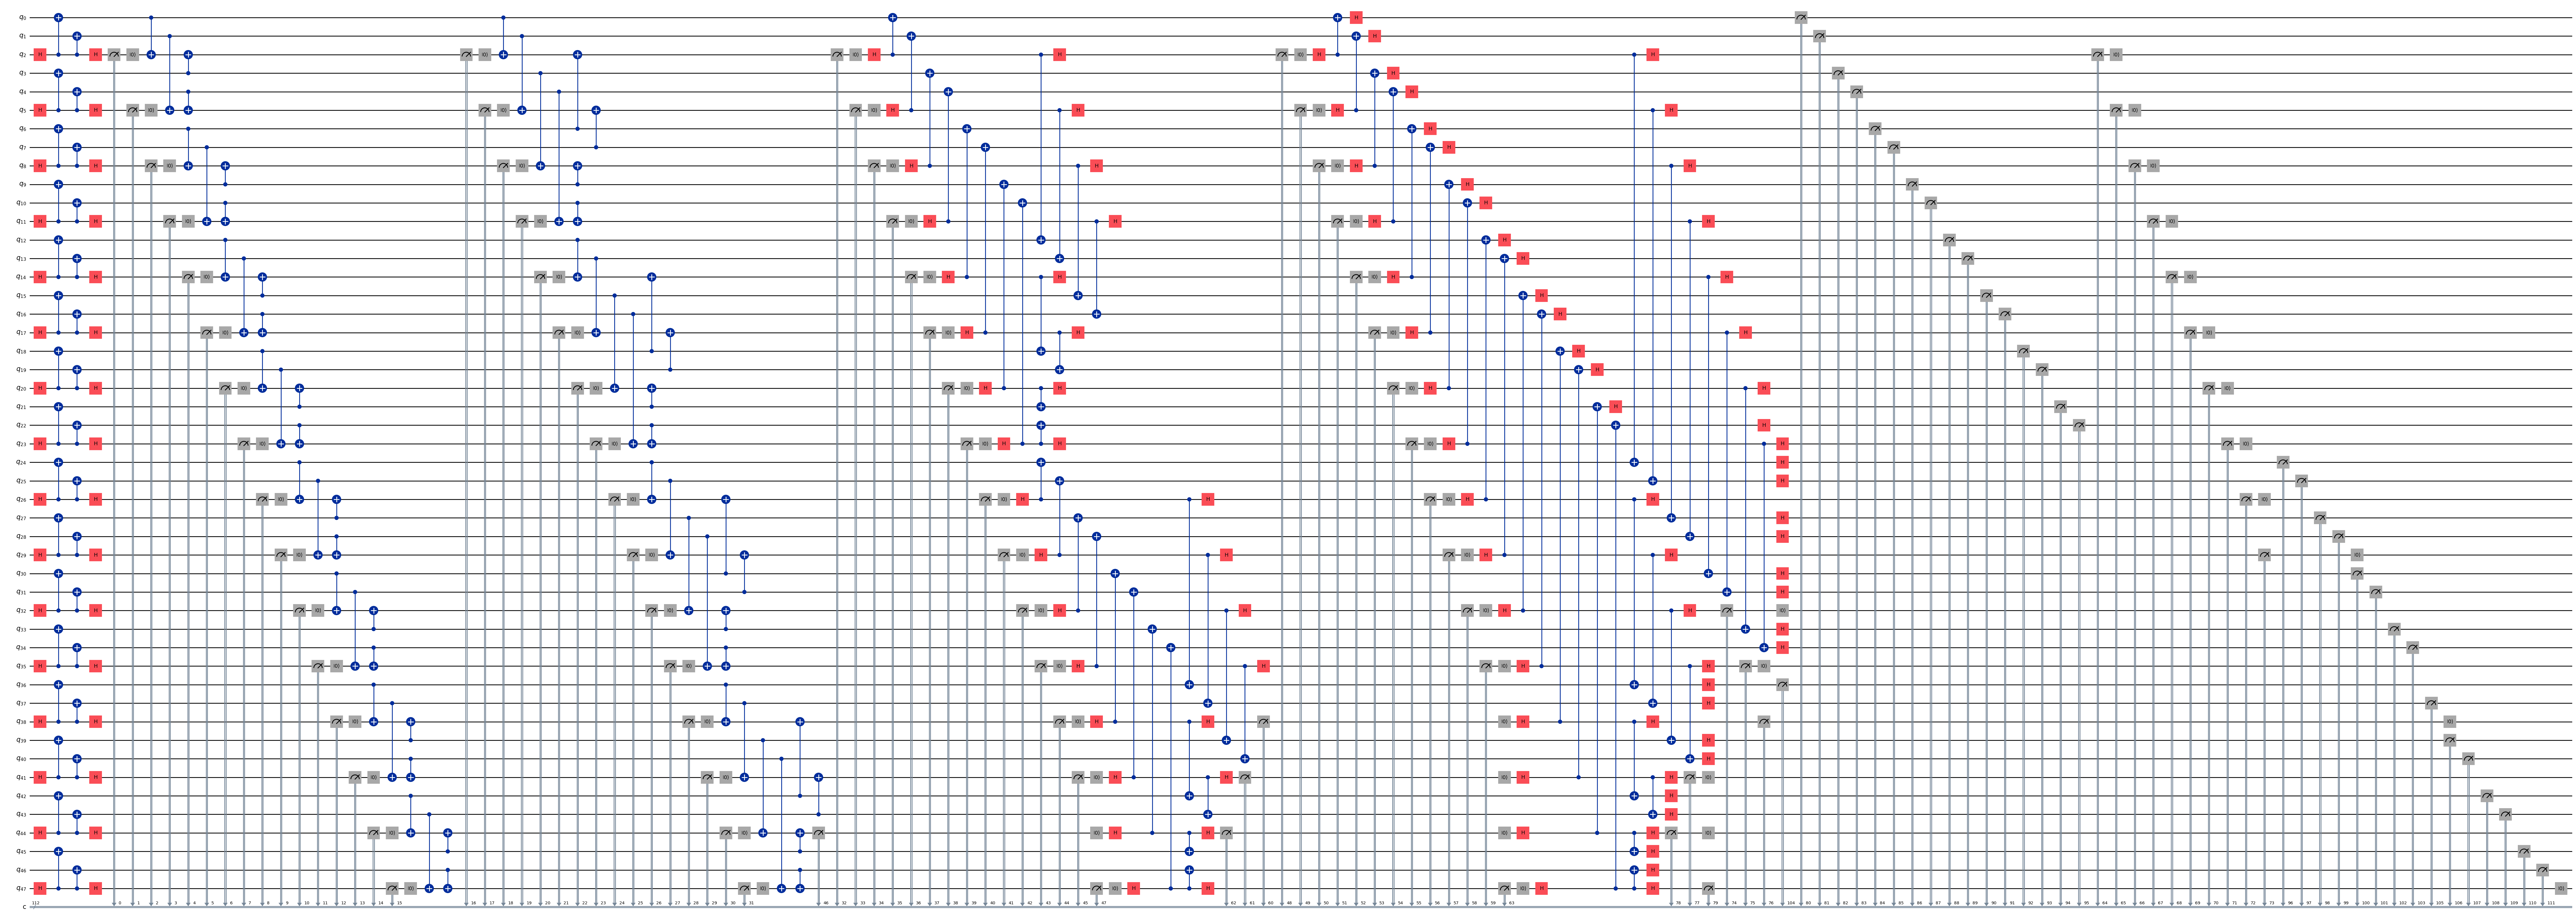

In [110]:
polar_n5_x_meas_data = polar_code_p2(5, True, "x", False)
polar_n5_x_meas_data.draw("mpl", fold=-1)

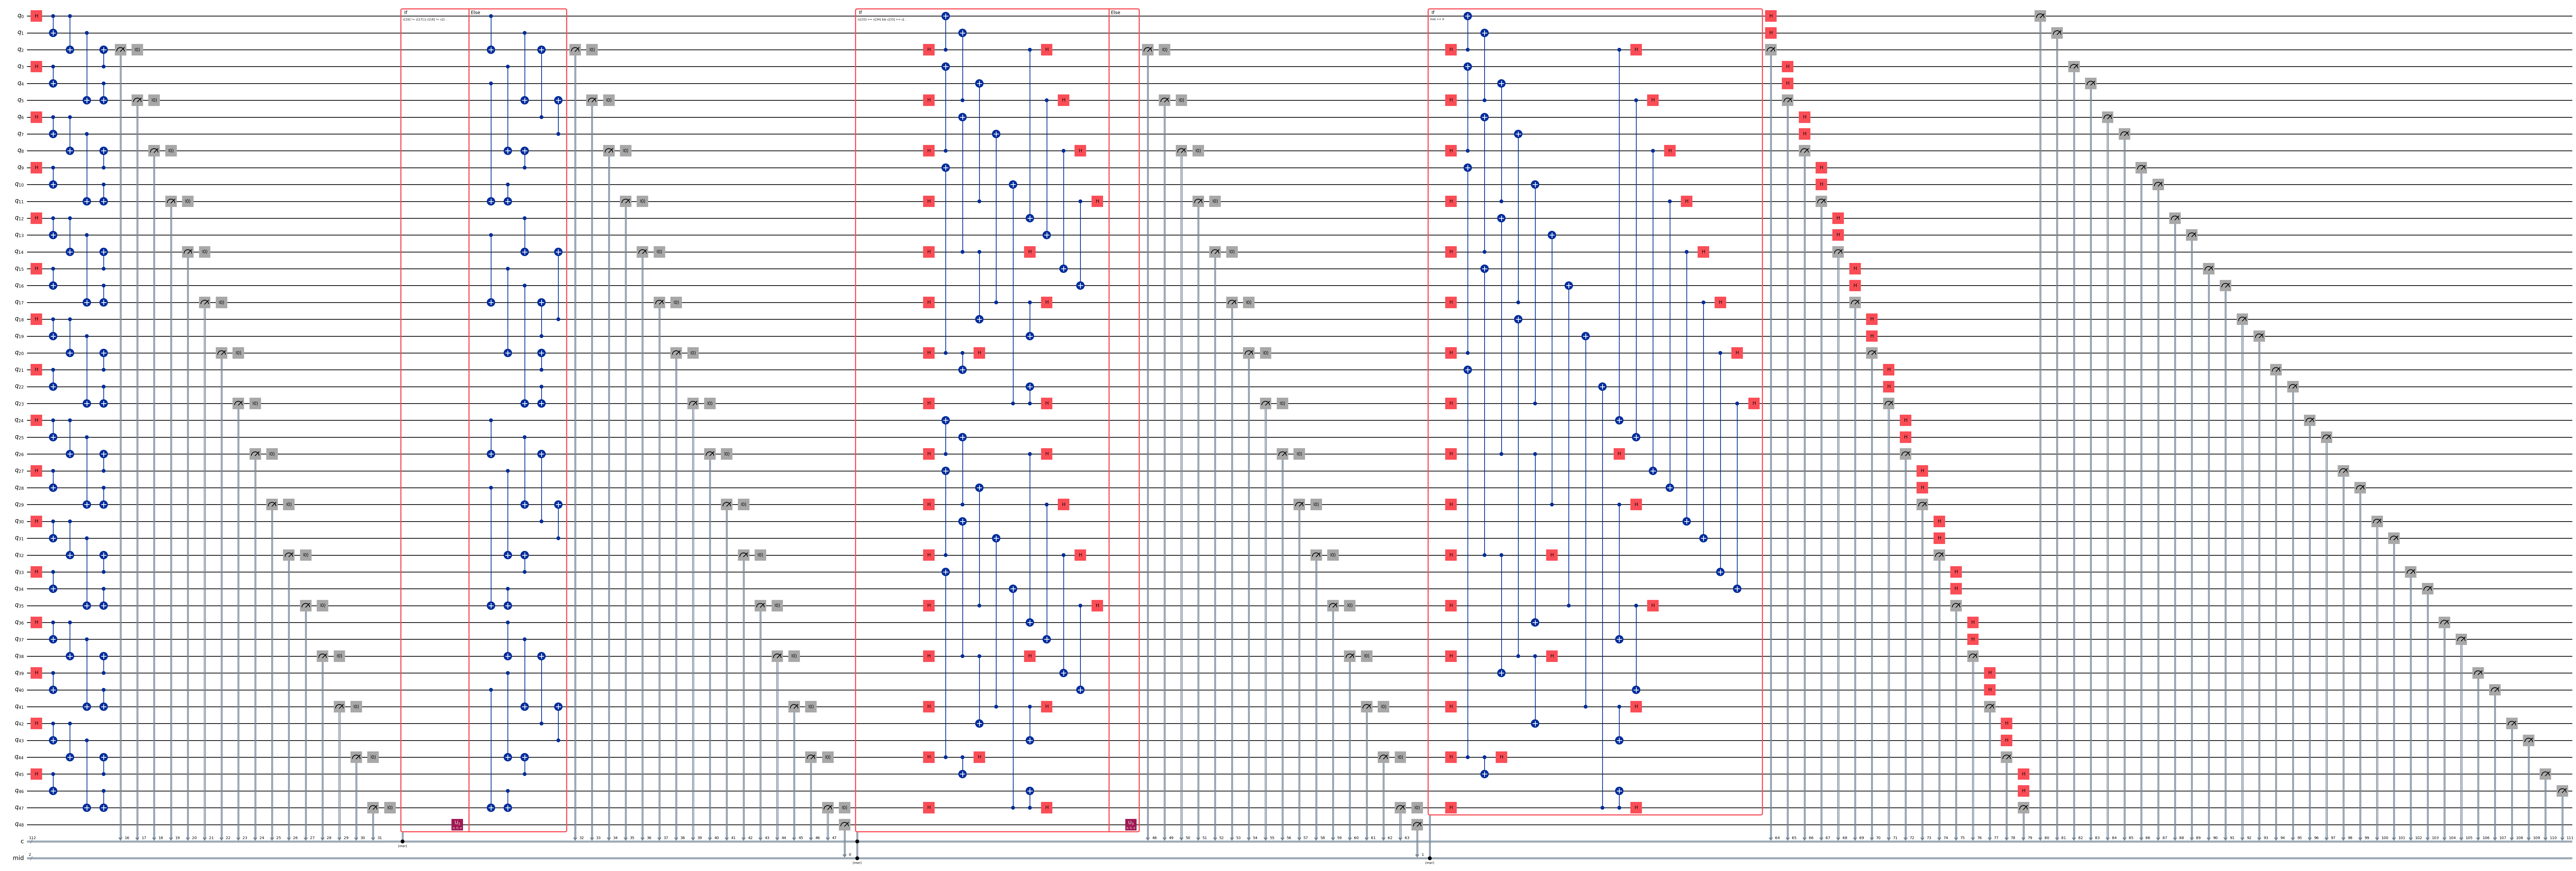

In [111]:
qreg = QuantumRegister(49, name="q")
creg = ClassicalRegister(112, name="c")
mid = ClassicalRegister(2, name="mid")
qc = QuantumCircuit(qreg,creg,mid)
m_idx = 0

for i in range(16):
    start = i * 3 
    qc.append(qc_x1_first, range(start, start + 3), [i])

# qc.barrier()

for i in range(8):
    start = i * 6
    qubits = range(start, start + 6)       
    clbits = range(2 * i + 4, 2 * i + 6)  
    qc.append(qc_z2, qubits, clbits)

# fix this it shold start from 16
m_idx = 16
for offset, qb in enumerate(range(2, 48, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

# expr_1 = expr.logic_or( expr.not_equal(creg[4], creg[5]), expr.not_equal(creg[6], creg[7]) )
expr_1 = expr.logic_or(
    expr.logic_or(
    expr.logic_or( expr.not_equal(creg[16], creg[17]), expr.not_equal(creg[18], creg[19]) ),
    expr.logic_or( expr.not_equal(creg[20], creg[21]), expr.not_equal(creg[22], creg[23]) )
    ),
    expr.logic_or(
    expr.logic_or( expr.not_equal(creg[24], creg[25]), expr.not_equal(creg[26], creg[27]) ),
    expr.logic_or( expr.not_equal(creg[28], creg[29]), expr.not_equal(creg[30], creg[31]) )
    )
)
with qc.if_test(expr_1) as else_:
    qc.x(48)

with else_:
    for i in range(4):    
        start = i * 12
        qubits = range(start, start + 12)
        clbits = range(4)
        qc.append(qc_z3, qubits, clbits)

qc.measure(48, mid[0])


for offset, qb in enumerate(range(2, 48, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

expr_2 = expr.logic_and(  
            expr.logic_and( 
                expr.logic_or( 
                    expr.logic_and(
                        expr.logic_and(expr.equal(creg[32], creg[34]) , expr.equal(creg[33], creg[35])),
                        expr.logic_and(expr.equal(creg[36], creg[38]) , expr.equal(creg[37], creg[39])) 
                    ),
                    expr.logic_and(
                        expr.logic_and(expr.not_equal(creg[32], creg[34]) , expr.not_equal(creg[33], creg[35])),
                        expr.logic_and(expr.not_equal(creg[36], creg[38]) , expr.not_equal(creg[37], creg[39])) 
                    )
                ),
                expr.logic_or( 
                    expr.logic_and(
                        expr.logic_and(expr.equal(creg[40], creg[42]) , expr.equal(creg[41], creg[43])),
                        expr.logic_and(expr.equal(creg[44], creg[46]) , expr.equal(creg[45], creg[47])) 
                    ),
                    expr.logic_and(
                        expr.logic_and(expr.not_equal(creg[40], creg[42]) , expr.not_equal(creg[41], creg[43])),
                        expr.logic_and(expr.not_equal(creg[44], creg[46]) , expr.not_equal(creg[45], creg[47])) 
                    )
                )
            ),
            expr.equal(mid, 0b00)
        )

    
with qc.if_test(expr_2) as else_:
    for i in range(2):    
        start = i * 24
        qubits = range(start, start + 24)
        clbits = range(8)
        qc.append(qc_x4, qubits, clbits)

with else_:
    qc.x(48)

qc.measure(48, mid[1])

for offset, qb in enumerate(range(2, 48, 3)): 
    qc.measure(qb, m_idx + offset)
    qc.reset(qb)

m_idx = m_idx + offset + 1

# qc.barrier()

expr_3 = expr.equal(mid, 0b00)
with qc.if_test(expr_3):
    for i in range(1):    
        start = i * 48
        qubits = range(start, start + 48)
        clbits = range(16)
        qc.append(qc_x5, qubits, clbits)

for offset, qb in enumerate(range(2, 48, 3)): 
    qc.measure(qb, m_idx + offset)

m_idx = m_idx + offset + 1

# qc.barrier()

qc = qc.decompose()

for i in (j for j in range(48) if j % 3 != 2):
    qc.h(i)
    qc.measure(i, m_idx)
    m_idx += 1

qc_h1 = qc
qc_h1.draw("mpl", fold=-1)

In [112]:
m_idx

112

#### Metric: Number of Operations


In [113]:
polar_n5_x_meas_data.count_ops()

OrderedDict([('cx', 160), ('h', 128), ('measure', 112), ('reset', 80)])

In [114]:
qc_h1.count_ops()

OrderedDict([('measure', 98),
             ('h', 48),
             ('cx', 48),
             ('reset', 48),
             ('if_else', 3)])

If an error is detected in the second layer, we will save:
- 46 measures gates
- 112 cx gates
- 112 hadamard gates

#### Metric : Quantum Resource

In [89]:
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# from qiskit_ibm_runtime.options import SamplerOptions

# tqc_1 = pm.run(polar_n5_x_meas_data)
# tqc_2 = pm.run(qc_h1)

# pubs_1 = [tqc_1]
# pubs_2 = [tqc_2]

# shots = 5000
# options = SamplerOptions(
#                 default_shots=shots,
#                 # dynamical_decoupling=dd_options,
#                 # twirling= twirling_options
#              )
# sampler = Sampler(mode=backend, options=options) 
# # job = sampler.run(pubs_1)
# # print(job.job_id(), hw_name)

# job = sampler.run(pubs_2)
# print(job.job_id(), hw_name)



In [90]:
# d1bapzkqf56g008zzsv0 ibm_sherbrooke normal (1m22s)
# d1bb77mv3z50008aevv0 ibm_sherbrooke dynamic (14s)

# chores.acetone-0t@icloud.com
# d1bbfcdn2txg008e9y60 ibm_sherbrooke dynamic (7s)

In [115]:
job_normal = service.job("d1bapzkqf56g008zzsv0")

result = job_normal.result()
res_1 = result[0].data.c.get_counts()

n = 5
lstate = "X"

count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate, res_1)

print(count_accept, count_logerror, count_undecided, ler, detect_normal, decoding_normal)


0 0 0 0 0.5690884069990716 0.008583377999457298


In [116]:
detect_normal + decoding_normal

0.5776717849985289

In [118]:
def update_count_dict_n5_t2_discard(count_ideal):
    creg_counts = {}
    total_discard = 0
    for key, value in count_ideal.items():
        key = key.replace(" ", "")  # remove spaces, just in case
        creg_part = key[-104:] + "00000000" 
        mid_part = key[:2]
        
        if "1" in mid_part:
            total_discard = total_discard + value
            continue

        creg_counts[creg_part] = creg_counts.get(creg_part, 0) + value

    print("Total discarded :", total_discard)
    return creg_counts


In [117]:
# chores.acetone-0t@icloud.com
token = "108bce3fd4c7a849d27b3eb41aad83f0c0a4f523cf6f3aa9735390405604613e51b9fc092722ef709554d9bb88a9dccd882eadeeadc590e554a8447fef8c8f97"
QiskitRuntimeService.save_account(channel="ibm_quantum", token=token, overwrite=True)
service = QiskitRuntimeService(channel="ibm_quantum", token=token)
# hw_name = "ibm_brisbane"
hw_name = "ibm_sherbrooke"
backend = service.backend(hw_name)

sim_ideal = AerSimulator()
sim_noisy = AerSimulator.from_backend(backend)

/tmp/ipykernel_105506/803816029.py:4: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = QiskitRuntimeService(channel="ibm_quantum", token=token)


In [ ]:
job_h1 = service.job("d1bbfcdn2txg008e9y60")

result_h1 = job_h1.result()
res_1 = result_h1[0].join_data().get_counts()

tmp_start_time  = time.perf_counter()
creg_counts = update_count_dict_n5_t2_discard(res_1)
tmp_end_time = time.perf_counter()
dec_filter_time = tmp_end_time - tmp_start_time


count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 = get_logical_error_on_accepted_states(n, lstate, creg_counts)

print(count_accept_h1, count_logerror_h1, count_undecided_h1, ler_h1, detect_h1, decoding_h1 )

Total discarded : 4842
0 0 0 0 0.021403073998953914 -0.0014302759991551284


In [121]:
detect_h1 + decoding_h1 + dec_filter_time

0.03930151599706733

### $n=6$, $i=23$ for logical $|0\rangle$, b = 011010

In [95]:
polar_n6_z_meas_data = polar_code_p2(6, True, "z", False)
polar_n6_z_meas_data.draw("mpl", fold=-1)

n = 6 , b = 011010 (22) , i = 23


In [96]:
polar_n6_z_meas_data.count_ops()

OrderedDict([('cx', 384), ('measure', 256), ('h', 192), ('reset', 192)])

### $n=6$, $i=22$ for logical $|+\rangle$, b = 101010

In [97]:
polar_n6_x_meas_data = polar_code_p2(6, True, "x", False)
polar_n6_x_meas_data.draw("mpl", fold=-1)

n = 6 , b = 101010 (21) , i = 22


In [98]:
polar_n6_x_meas_data.count_ops()

OrderedDict([('cx', 320), ('h', 256), ('measure', 224), ('reset', 160)])

### Summary


These are the summary of the reduction of number of gates being executed if error is detected on the Layer 2


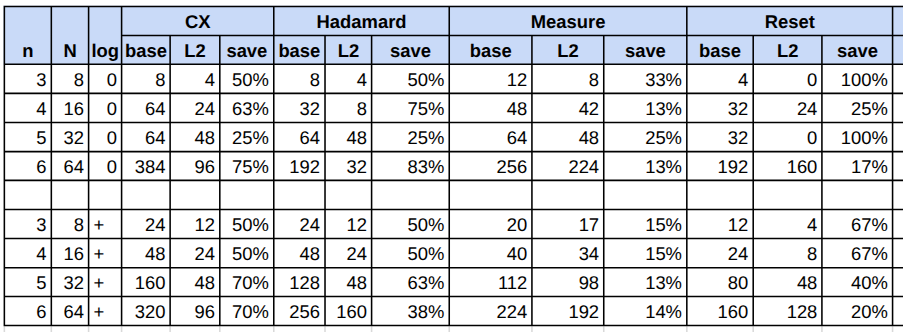

With this reduction on the number of executed gates, we would expect the reduction of the usage of quantum resource

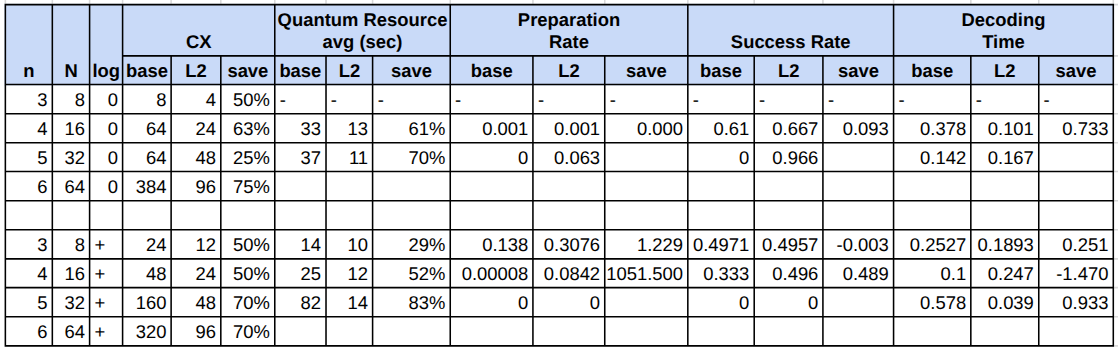

#### Drawbacks

Overhead in the usage of qubits and cbits:
- 1 extra qubit
- c extra cbits (c = number of error detection) where $c <= n - 2$



#### Conclusion

abc

## Fault-tolerant approach